Causal Inference Methods in Software Engineering: A GitHub Actions Example

Purpose of dissertation: To compare causal inference techniques for estimating effects from observational software-repository data.

Adoption of GitHub Actions and repository commits are the empirical example used to evaluate the following causal inference methods:

- Regression Adjustment (Ordinary Least Squares, OLS): includes observed repository features in the outcome regression.
- Propensity Score Matching (PSM): creates more comparable groups of adopters and non-adopters using pre-treatment features.
- Difference-in-Differences (DiD): compares changes in commits before and after adoption between treated repositories and their matched controls, using the treated repository's adoption time.
- Doubly Robust Difference-in-Differences (DR-DiD):combines the DiD framework with propensity-score adjustment and outcome regression.

The data are retrieved directly from GitHub using its API. There are specific sample requirements depending on the applied method at certain steps, such as an identifiable adoption time and sufficient pre- and post-adoption observation periods.

The purpose of this notebook is to implement and compare these methods, focusing on how they construct treatment and control groups, which assumptions they require, and how the resulting estimates differ.

GitHub API requests are conducted concurrently while respecting the API rate limits to reduce the overall data-collection time.

Before running: set GITHUB_TOKEN as a Colab secret (using key icon in the left sidebar) or as environment variable locally.

### 1. Setup

In [ ]:
!pip install -q linearmodels tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.0 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
import threading
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm
from linearmodels.panel import PanelOLS

pd.set_option("display.max_columns", 50)


In [ ]:

# GitHub authentication
try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
except ImportError:
    GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")

if not GITHUB_TOKEN:
    raise ValueError("GITHUB_TOKEN not found. Set it in Colab secrets or as an env var.")

HEADERS = {
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
}

# Verifies that the token is available
resp = requests.get("https://api.github.com/rate_limit", headers=HEADERS)
print("Status:", resp.status_code)
print("Remaining requests:", resp.json()["resources"]["core"]["remaining"])


Status: 200
Remaining requests: 5000


### 2. Shared rate-limited HTTP client

All later stages (search, adoption detection, metadata enrichment, commit panel fetch) share this thread-safe rate limiter and connection-pooled session, This is used to control API requests when the data-collection stages run concurrently.


In [ ]:
class GitHubRateLimiter:
    def __init__(self, buffer=50):
        self._lock = threading.Lock()
        self._remaining = 5000
        self._reset_at = time.time() + 3600
        self._buffer = buffer

    def update(self, resp):
        with self._lock:
            try:
                self._remaining = int(resp.headers.get("X-RateLimit-Remaining", self._remaining))
                self._reset_at = int(resp.headers.get("X-RateLimit-Reset", self._reset_at))
            except (TypeError, ValueError):
                pass

    def wait_if_needed(self):
        with self._lock:
            remaining, reset_at = self._remaining, self._reset_at
        if remaining <= self._buffer:
            wait_s = max(reset_at - time.time(), 0) + 2
            if wait_s > 0:
                print(f"[rate limiter] {remaining} left, sleeping {wait_s:.0f}s")
                time.sleep(wait_s)


RATE_LIMITER = GitHubRateLimiter()
_thread_local = threading.local()


def get_session(headers):
    if not hasattr(_thread_local, "session"):
        s = requests.Session()
        s.headers.update(headers)
        s.mount("https://", requests.adapters.HTTPAdapter(pool_connections=20, pool_maxsize=20))
        _thread_local.session = s
    return _thread_local.session


def gh_get(url, headers, params=None, max_retries=5, timeout=30):
    session = get_session(headers)
    for attempt in range(max_retries):
        RATE_LIMITER.wait_if_needed()
        try:
            resp = session.get(url, params=params, timeout=timeout)
        except requests.RequestException:
            time.sleep(min(2 ** attempt, 20))
            continue
        RATE_LIMITER.update(resp)
        if resp.status_code == 200:
            return resp
        if resp.status_code in (404, 409, 451):
            return resp
        if resp.status_code in (403, 429, 500, 502, 503, 504):
            time.sleep(min(2 ** attempt * 2, 60))
            continue
        return resp
    return None


def get_last_page_num(link_header):
    if not link_header:
        return None
    m = re.search(r'page=(\d+)>; rel="last"', link_header)
    return int(m.group(1)) if m else None


### 3. Stage 1 - Search candidate repositories

Repositories are sampled across programming languages and star levels because only a subset will have a verifiable GitHub Actions adoption date and sufficient pre- and post-adoption history.


In [ ]:
def search_repositories(query, headers, pages=10):
    repos = []
    for page in range(1, pages + 1):
        resp = gh_get(
              "https://api.github.com/search/repositories", headers,
            params={"q": query, "sort": "stars", "order": "desc", "per_page": 100, "page": page},
        )
        if resp is None or resp.status_code != 200:
            break

        items = resp.json().get("items", [])

        if not items:
            break
        for item in items:
            repos.append({
                "repo_full_name": item["full_name"],
                "owner": item["owner"]["login"],
                "repo_name": item["name"],
                "language": item["language"],
                "stars": item["stargazers_count"],
                "forks": item["forks_count"],
                "created_at": item["created_at"],
                "updated_at": item["updated_at"],
                "default_branch": item["default_branch"],
                "fork": item.get("fork", False),
                "archived": item.get("archived", False),
            })
        time.sleep(2.2)  # search API: 30 req/min limit
    return repos


def build_candidate_pool(headers, languages=None, stars_threshold=200, pages_per_query=10):
    if languages is None:
        languages = ["Python", "JavaScript", "TypeScript", "Java", "Go", "Rust",
                     "C", "C++", "Ruby", "PHP", "C#", "Kotlin"]

    queries = [f"language:{lang} stars:>{stars_threshold}" for lang in languages]

    all_repos = []
    for q in queries:
        print(f"Searching: {q}")
        all_repos.extend(search_repositories(q, headers, pages=pages_per_query))

    df = pd.DataFrame(all_repos).drop_duplicates(subset="repo_full_name").reset_index(drop=True)
    df = df[(~df["fork"]) & (~df["archived"])].reset_index(drop=True)
    print(f"Total unique, non-fork, non-archived candidates: {len(df)}")
    return df


In [ ]:
# Adjust the values of the stars_threshold and pages_per_query parameters to control the size of the candidate pool.
# ~10 pages x 12 languages x 100/page = up to 12,000 candidates before de-duplication.
candidates = build_candidate_pool(HEADERS, stars_threshold=200, pages_per_query=10)
candidates.to_csv("candidates_raw.csv", index=False)
candidates.head()


In [ ]:
candidates=pd.read_csv("/content/candidates_raw.csv")

### 3. Stage 2 - Current workflow check

This step identifies whether each repository currently contains a .github/workflows directory before performing the more expensive historical search for an adoption date.


In [ ]:
def _check_current_workflow(repo_full_name, headers):
    url = f"https://api.github.com/repos/{repo_full_name}/contents/.github/workflows"
    resp = gh_get(url, headers)
    if resp is None:
        return repo_full_name, None
    if resp.status_code == 200:
        return repo_full_name, 1
    if resp.status_code == 404:
        return repo_full_name, 0
    return repo_full_name, None


def check_current_state_concurrent(repo_list, headers, max_workers=8):
    results = {}
    completed = 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {}
        for repo in repo_list:
            time.sleep(0.02)  # Stagger requests slightly to reduce concurrent request bursts
            futures[ex.submit(_check_current_workflow, repo, headers)] = repo

        for f in as_completed(futures):
            repo, status = f.result()
            results[repo] = status
            completed += 1
            if completed % 200 == 0 or completed == len(futures):
                print(f"  {completed}/{len(futures)} checked...")

    return results

In [ ]:
# Inspect candidate-pool size and current rate-limit status
print("Candidates to check:", len(candidates))
print("Rate limiter state:", RATE_LIMITER._remaining, "remaining, resets in", RATE_LIMITER._reset_at - time.time(), "seconds")

# Test a small sample sequentially
for repo in candidates["repo_full_name"].head(5):
    r = requests.get(f"https://api.github.com/repos/{repo}/contents/.github/workflows", headers=HEADERS)
    print(repo, "->", r.status_code, "| remaining:", r.headers.get("X-RateLimit-Remaining"))

Candidates to check: 11154
Rate limiter state: 29 remaining, resets in -38.50280833244324 seconds
public-apis/public-apis -> 200 | remaining: 4999
EbookFoundation/free-programming-books -> 200 | remaining: 4998
donnemartin/system-design-primer -> 404 | remaining: 4997
vinta/awesome-python -> 200 | remaining: 4996
practical-tutorials/project-based-learning -> 200 | remaining: 4995


In [ ]:
candidates = candidates.sample(n=2000, random_state=42).reset_index(drop=True)
print("Trimmed candidate pool:", len(candidates))
candidates.to_csv("candidates_trimmed.csv", index=False)

Trimmed candidate pool: 2000


In [ ]:
current_state = check_current_state_concurrent(candidates["repo_full_name"].tolist(), HEADERS)
candidates["github_actions_enabled"] = candidates["repo_full_name"].map(current_state)
candidates = candidates.dropna(subset=["github_actions_enabled"]).copy()
candidates["github_actions_enabled"] = candidates["github_actions_enabled"].astype(int)

print(candidates["github_actions_enabled"].value_counts())
candidates.to_csv("candidates_with_current_state.csv",index=False)


In [ ]:
candidates=pd.read_csv("/content/candidates_with_current_state.csv")

In [ ]:
candidates.head()

,repo_full_name,owner,repo_name,language,stars,forks,created_at,updated_at,default_branch,fork,archived,github_actions_enabled
0,v2rayA/v2rayA,v2rayA,v2rayA,Go,15400,1571,2019-10-18T20:42:06Z,2026-07-23T12:52:20Z,main,False,False,1
1,Kotlin/dokka,Kotlin,dokka,Kotlin,3791,491,2014-07-12T09:15:22Z,2026-07-23T09:09:40Z,master,False,False,1
2,php-embed/Embed,php-embed,Embed,PHP,2142,324,2012-10-09T21:14:58Z,2026-07-20T02:01:19Z,master,False,False,1
3,jagenjo/litegraph.js,jagenjo,litegraph.js,JavaScript,8083,839,2013-09-26T17:39:05Z,2026-07-23T10:48:33Z,master,False,False,0
4,albertlauncher/albert,albertlauncher,albert,C++,7964,328,2014-07-25T14:08:30Z,2026-07-21T18:17:50Z,main,False,False,1


### 4. Stage 3 - Identifying GitHub Actions adoption dates

For repositories currently using GitHub Actions, the adoption date is approximated using the earliest observable commit that modified .github/workflows. The GitHub commits API is filtered by this path, and the oldest matching commit is used as the reference adoption date.


In [ ]:

def _get_adoption_date(repo_full_name, headers):
    url = f"https://api.github.com/repos/{repo_full_name}/commits"
    resp = gh_get(url, headers, params={"path": ".github/workflows", "per_page": 1})
    if resp is None or resp.status_code != 200:
        return repo_full_name, None, "error"
    data = resp.json()
    if not data:
        return repo_full_name, None, "no_history_found"

    last_page = get_last_page_num(resp.headers.get("Link"))
    if last_page:
        resp2 = gh_get(url, headers, params={"path": ".github/workflows", "per_page": 1, "page": last_page})
        if resp2 is None or resp2.status_code != 200:
            return repo_full_name, None, "error"
        data2 = resp2.json()
        if not data2:
            return repo_full_name, None, "no_history_found"
        date_str = data2[0]["commit"]["committer"]["date"]
    else:
        date_str = data[0]["commit"]["committer"]["date"]

    return repo_full_name, date_str[:10], "ok"


def get_adoption_dates_concurrent(repo_list, headers, max_workers=15):
    records = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_get_adoption_date, repo, headers): repo for repo in repo_list}
        for f in tqdm(as_completed(futures), total=len(futures), desc="Finding adoption dates"):
            repo, date_str, status = f.result()
            records.append({"repo_full_name": repo, "adoption_date": date_str, "status": status})
    return pd.DataFrame(records)


In [ ]:

treated_candidates = candidates[candidates["github_actions_enabled"] == 1]["repo_full_name"].tolist()
adoption_df = get_adoption_dates_concurrent(treated_candidates, HEADERS)

print(adoption_df["status"].value_counts())
adoption_df.to_csv("adoption_dates_raw.csv", index=False)
adoption_df.head()


Finding adoption dates:   0%|          | 0/1433 [00:00<?, ?it/s]

status
ok    1433
Name: count, dtype: int64


,repo_full_name,adoption_date,status
0,v2rayA/v2rayA,2020-02-15,ok
1,killme2008/aviatorscript,2023-05-15,ok
2,albertlauncher/albert,2023-05-05,ok
3,KeygraphHQ/shannon,2026-03-18,ok
4,psf/requests,2020-10-01,ok


In [ ]:
adoption_df=pd.read_csv("/content/adoption_dates_raw.csv")

### 5. Stage 4 - Eligibility filter

For the longitudinal analyses, treated repositories must have sufficient time available around the identified adoption date. A repository is retained if it was created at least 12 months before adoption and at least 12 months have elapsed after adoption. This provides the required pre- and post-treatment time window for the subsequent panel-data collection.


In [ ]:

def filter_eligible_adopters(adoption_df, repo_meta_df, months_before=12, months_after=12):
    df = adoption_df[adoption_df["status"] == "ok"].copy()
    df["adoption_date"] = pd.to_datetime(df["adoption_date"], utc=True, errors="coerce")
    df = df.dropna(subset=["adoption_date"])

    df = df.merge(repo_meta_df[["repo_full_name", "created_at"]], on="repo_full_name", how="left")
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")

    now = pd.Timestamp(datetime.now(timezone.utc))
    df["has_post_window"] = df["adoption_date"] + pd.DateOffset(months=months_after) <= now
    df["has_pre_window"] = df["adoption_date"] - pd.DateOffset(months=months_before) >= df["created_at"]

    eligible = df[df["has_post_window"] & df["has_pre_window"]].copy()
    print(f"Adoption dates found: {len(df)} | Eligible (full ±{months_before}mo window observable): {len(eligible)}")
    return eligible


eligible_treated = filter_eligible_adopters(adoption_df, candidates)
eligible_treated.to_csv("eligible_treated_repos.csv", index=False)
eligible_treated.head()


Adoption dates found: 1433 | Eligible (full ±12mo window observable): 904


,repo_full_name,adoption_date,status,created_at,has_post_window,has_pre_window
1,killme2008/aviatorscript,2023-05-15 00:00:00+00:00,ok,2011-03-29 12:48:47+00:00,True,True
2,albertlauncher/albert,2023-05-05 00:00:00+00:00,ok,2014-07-25 14:08:30+00:00,True,True
4,psf/requests,2020-10-01 00:00:00+00:00,ok,2011-02-13 18:38:17+00:00,True,True
5,wangeditor-team/wangEditor,2021-07-25 00:00:00+00:00,ok,2014-11-06 09:26:47+00:00,True,True
6,Kotlin/dokka,2020-05-19 00:00:00+00:00,ok,2014-07-12 09:15:22+00:00,True,True


In [ ]:
candidates.columns

Index(['repo_full_name', 'owner', 'repo_name', 'language', 'stars', 'forks',
       'created_at', 'updated_at', 'default_branch', 'fork', 'archived',
       'github_actions_enabled'],
      dtype='object')

### 6. Stage 5 - Repository metadata enrichment

This stage involves collecting repository level metrics, such as number of commits, pull requests, and contributors. A checkpoint file is used so that the collection using API can resume without having to process repositories that had already been processed before.

In [ ]:
def enrich_metadata_concurrent(repo_list, headers, checkpoint_path="enrichment_checkpoint.csv", max_workers=8):
  # Save each completed repository so the API collection can resume after interruption
    if os.path.exists(checkpoint_path):
        done_df = pd.read_csv(checkpoint_path)
        done_repos = set(done_df["repo_full_name"])
        print(f"Resuming: {len(done_repos)} already done, {len(repo_list) - len(done_repos)} left")
    else:
        done_repos = set()

    remaining = [r for r in repo_list if r not in done_repos]
    write_lock = threading.Lock()

    def _process_and_save(repo):
        repo, commits, prs, contributors = _enrich_one_repo(repo, headers)
        row = {"repo_full_name": repo, "commits_count": commits,
               "pull_requests_count": prs, "contributors_count": contributors}
        with write_lock:
            pd.DataFrame([row]).to_csv(checkpoint_path, mode="a",header=not os.path.exists(checkpoint_path), index=False)
        return row

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_process_and_save, repo): repo for repo in remaining}
        for i, f in enumerate(as_completed(futures), 1):
            f.result()
            if i % 100 == 0:
                print(f"  {i}/{len(remaining)} done this run")

    return pd.read_csv(checkpoint_path)

def _count_via_link_header(url, headers, params=None):
    params = dict(params or {})
    params["per_page"] = 1
    resp = gh_get(url, headers, params=params)
    if resp is None or resp.status_code != 200:
        return np.nan
    last_page = get_last_page_num(resp.headers.get("Link"))
    if last_page:
        return last_page
    data = resp.json()
    return len(data) if isinstance(data, list) else np.nan


def _enrich_one_repo(repo_full_name, headers):
    commits = _count_via_link_header(f"https://api.github.com/repos/{repo_full_name}/commits", headers)
    prs = _count_via_link_header(f"https://api.github.com/repos/{repo_full_name}/pulls", headers, {"state": "all"})
    contributors = _count_via_link_header(f"https://api.github.com/repos/{repo_full_name}/contributors", headers)
    return repo_full_name, commits, prs, contributors

In [ ]:
candidates_final  = candidates.sample(n=500, random_state=42).reset_index(drop=True)
enrichment_df = enrich_metadata_concurrent(candidates_final["repo_full_name"].tolist(), HEADERS, max_workers=8)


[rate limiter] 24 left, sleeping 416s
[rate limiter] 24 left, sleeping 416s
[rate limiter] 24 left, sleeping 416s
[rate limiter] 24 left, sleeping 416s
[rate limiter] 24 left, sleeping 416s
[rate limiter] 24 left, sleeping 416s
[rate limiter] 24 left, sleeping 416s
[rate limiter] 24 left, sleeping 416s
  100/500 done this run
  200/500 done this run
  300/500 done this run
  400/500 done this run
  500/500 done this run


In [ ]:
enrichment_df.to_csv("enrichment_raw.csv", index=False)
enrichment_df.head()

In [ ]:
current_state = check_current_state_concurrent(candidates_final["repo_full_name"].tolist(), HEADERS, max_workers=8)
candidates_final["github_actions_enabled"] = candidates_final["repo_full_name"].map(current_state)
candidates_final = candidates_final.dropna(subset=["github_actions_enabled"]).copy()
candidates_final["github_actions_enabled"] = candidates_final["github_actions_enabled"].astype(int)

candidates_final.to_csv("candidates_final_with_state.csv", index=False)
print(candidates_final["github_actions_enabled"].value_counts())

In [ ]:
import pandas as pd
candidates = pd.read_csv("candidates_with_current_state.csv")
print(candidates["github_actions_enabled"].value_counts())

['repo_full_name', 'owner', 'repo_name', 'language', 'stars', 'forks', 'created_at', 'updated_at', 'default_branch', 'fork', 'archived', 'github_actions_enabled']
github_actions_enabled
1    1433
0     567
Name: count, dtype: int64


In [ ]:
enrichment_df=pd.read_csv('/content/enrichment_raw.csv')

### 7. Build the 500-repository cross-sectional dataset
This dataset is used for the cross-sectional Regression Adjustment analysis. Repository-level counts are merged with the candidate metadata, annualized relative to repository age, and log transformations are created for the variables used in the OLS model.

In [ ]:

def build_analysis_dataframe(candidates_df, enrichment_df):
    df = candidates_df.merge(enrichment_df, on="repo_full_name", how="left")
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
    now = pd.Timestamp.now(tz="UTC")
    df["repo_age_years"] = (now - df["created_at"]).dt.days / 365
    df["commits_per_year"] = df["commits_count"] / df["repo_age_years"]
    df["prs_per_year"] = df["pull_requests_count"] / df["repo_age_years"]
    df["contributors_per_year"] = df["contributors_count"] / df["repo_age_years"]
    df["log_stars"] = np.log1p(df["stars"])
    df["log_forks"] = np.log1p(df["forks"])
    df["log_commits_per_year"] = np.log1p(df["commits_per_year"].clip(lower=0))
    return df.drop_duplicates(subset="repo_full_name").reset_index(drop=True)


def sample_500(df, target_total=500, random_state=42):
    df = df.dropna(subset=["commits_count", "pull_requests_count", "contributors_count", "language"]).copy()
    if len(df) <= target_total:
        print(f"Only {len(df)} eligible repos available (< target {target_total}) - keeping all.")
        return df.reset_index(drop=True)
    return df.sample(n=target_total, random_state=random_state).reset_index(drop=True)


analysis_df = build_analysis_dataframe(candidates, enrichment_df)
analysis_df = sample_500(analysis_df, target_total=500)

print("Final dataset shape:", analysis_df.shape)
print(analysis_df["github_actions_enabled"].value_counts())

analysis_df.to_csv("github_repos_final_500.csv", index=False)
analysis_df.head()


Final dataset shape: (500, 22)
github_actions_enabled
1    367
0    133
Name: count, dtype: int64


,repo_full_name,owner,repo_name,language,stars,forks,created_at,updated_at,default_branch,fork,archived,github_actions_enabled,commits_count,pull_requests_count,contributors_count,repo_age_years,commits_per_year,prs_per_year,contributors_per_year,log_stars,log_forks,log_commits_per_year
0,asb2m10/dexed,asb2m10,dexed,C++,3436,292,2013-12-06 04:18:54+00:00,2026-07-22T16:02:44Z,master,False,False,1,532.0,97.0,19.0,12.723288,41.813092,7.623816,1.493325,8.142354,5.680173,3.756844
1,markdoc/markdoc,markdoc,markdoc,TypeScript,8080,230,2022-05-09 17:50:46+00:00,2026-07-23T10:41:05Z,main,False,False,1,162.0,188.0,22.0,4.293151,37.734525,43.790683,5.124442,8.997271,5.442418,3.656731
2,yudaocode/SpringBoot-Labs,yudaocode,SpringBoot-Labs,Java,20094,6150,2018-09-12 14:51:46+00:00,2026-07-23T04:44:47Z,master,False,False,0,678.0,37.0,3.0,7.950685,85.275672,4.653687,0.377326,9.908226,8.724370,4.457548
3,libreddit/libreddit,libreddit,libreddit,Rust,5202,255,2020-08-12 00:17:58+00:00,2026-07-23T15:35:37Z,master,False,False,1,958.0,264.0,79.0,6.035616,158.724467,43.740354,13.088970,8.556991,5.545177,5.073450
4,FunAudioLLM/CosyVoice,FunAudioLLM,CosyVoice,Python,22364,2584,2024-07-03 02:59:22+00:00,2026-07-23T17:24:02Z,main,False,False,1,552.0,250.0,43.0,2.142466,257.647059,116.687980,20.070332,10.015253,7.857481,5.555464


### 8. Basic EDA

The cross-sectional sample is examined before regression modelling to check missing values and compare basic repository characteristics by GitHub Actions adoption status. These comparisons are descriptive only and are not interpreted causally.

Shape: (500, 22)

Missing values:
 repo_full_name            0
owner                     0
repo_name                 0
language                  0
stars                     0
forks                     0
created_at                0
updated_at                0
default_branch            0
fork                      0
archived                  0
github_actions_enabled    0
commits_count             0
pull_requests_count       0
contributors_count        0
repo_age_years            0
commits_per_year          0
prs_per_year              0
contributors_per_year     0
log_stars                 0
log_forks                 0
log_commits_per_year      0
dtype: int64


,stars,forks,repo_age_years,commits_per_year,prs_per_year,contributors_per_year
github_actions_enabled,,,,,,
0,8491.95,1484.76,9.24,786.45,137.33,4.79
1,12332.42,1969.19,8.63,869.85,383.92,20.88


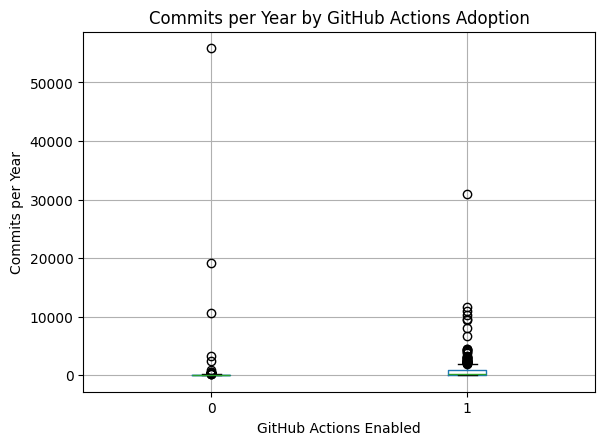

In [ ]:

print("Shape:", analysis_df.shape)
print("\nMissing values:\n", analysis_df.isnull().sum())

eda_summary = (
    analysis_df.groupby("github_actions_enabled")[["stars", "forks", "repo_age_years", "commits_per_year", "prs_per_year", "contributors_per_year"]].mean().round(2)
)
display(eda_summary)

analysis_df.boxplot(column="commits_per_year", by="github_actions_enabled")
plt.title("Commits per Year by GitHub Actions Adoption")
plt.suptitle("")
plt.xlabel("GitHub Actions Enabled")
plt.ylabel("Commits per Year")
plt.show()


### 9. Technique 1 - OLS

The research examines the association between the use of GitHub Actions and commit activity on an annual basis. The covariates observed include age of the repository, number of stars, forks, and the programming language. HC1 robust standard errors are used due to heteroskedasticity in the residual tests.


In [ ]:

def run_ols(df):
    reg_df = df[["github_actions_enabled", "commits_per_year", "repo_age_years","log_stars", "log_forks", "language"]].dropna().copy()
    reg_df["log_commits_per_year"] = np.log1p(reg_df["commits_per_year"].clip(lower=0))

    model = smf.ols("log_commits_per_year ~ github_actions_enabled + repo_age_years + log_stars + log_forks + C(language)",data=reg_df,).fit(cov_type="HC1")

    print(model.summary())

    coef = model.params["github_actions_enabled"]
    pval = model.pvalues["github_actions_enabled"]
    pct_effect = (np.exp(coef) - 1) * 100
    print(f"\nGitHub Actions coefficient: {coef:.4f} (p={pval:.4f})")
    print(f"Approx. percentage difference associated with GitHub Actions adoption: {pct_effect:.2f}%")

    return model, reg_df


ols_model, ols_reg_df = run_ols(analysis_df)


                             OLS Regression Results                             
Dep. Variable:     log_commits_per_year   R-squared:                       0.375
Model:                              OLS   Adj. R-squared:                  0.356
Method:                   Least Squares   F-statistic:                     21.31
Date:                  Thu, 20 Aug 2026   Prob (F-statistic):           2.43e-44
Time:                          15:55:50   Log-Likelihood:                -866.29
No. Observations:                   500   AIC:                             1765.
Df Residuals:                       484   BIC:                             1832.
Df Model:                            15                                         
Covariance Type:                    HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

### Residual normality: Jarque–Bera test
The Jarque–Bera test is used to assess whether the OLS residuals are consistent with a normal distribution.

Null hypothesis (H0): The residuals are normally distributed.

Alternative hypothesis (H1): The residuals depart from normality.

In [ ]:
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(ols_model.resid)

print(f"Jarque-Bera statistic: {jb_stat:.3f}")
print(f"p-value: {jb_pvalue:.6f}")
print(f"Skewness: {skew:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")

The Jarque–Bera test is statistically significant (JB = 29.026, p<0.001). Therefore, the null hypothesis of normally distributed residuals is rejected.

### Descriptive Statistics

In [ ]:
def descriptive_stats_table(df, group_col="github_actions_enabled"):
    numeric_cols = ["commits_per_year", "repo_age_years", "stars", "forks",
                     "contributors_per_year", "prs_per_year"]

    overall = df[numeric_cols].describe().T[["mean", "std", "min", "max"]]
    overall.columns = ["Mean", "SD", "Min", "Max"]


    by_group = df.groupby(group_col)[numeric_cols].mean().T
    by_group.columns = ["Non-adopters (mean)", "Adopters (mean)"]

    table = overall.join(by_group)
    print(table.round(2))
    table.to_csv("descriptive_statistics_table.csv")
    return table

descriptive_stats_table(analysis_df)

                           Mean        SD     Min        Max  \
commits_per_year         847.66   3251.30    1.20   55862.22   
repo_age_years             8.80      4.53    0.22      18.50   
stars                  11310.85  14375.97  973.00  114537.00   
forks                   1840.33   3722.91    9.00   44947.00   
contributors_per_year     16.60     31.25    0.00     405.95   
prs_per_year             318.33   1183.86    0.00   18646.93   

                       Non-adopters (mean)  Adopters (mean)  
commits_per_year                    786.45           869.85  
repo_age_years                        9.24             8.63  
stars                              8491.95         12332.42  
forks                              1484.76          1969.19  
contributors_per_year                 4.79            20.88  
prs_per_year                        137.33           383.92  


,Mean,SD,Min,Max,Non-adopters (mean),Adopters (mean)
commits_per_year,847.664075,3251.300402,1.195415,55862.221955,786.452323,869.847081
repo_age_years,8.795260,4.526944,0.216438,18.504110,9.240025,8.634079
stars,11310.852000,14375.970832,973.000000,114537.000000,8491.947368,12332.416894
forks,1840.328000,3722.910672,9.000000,44947.000000,1484.759398,1969.185286
contributors_per_year,16.602600,31.251874,0.000000,405.945513,4.789135,20.883774
prs_per_year,318.330830,1183.864071,0.000000,18646.931452,137.331882,383.924454


### Correlation Matrix
The correlation matrix provides a first look at the relationship between pairs of variables. It should be pointed out that the presence of high correlations between predictors may imply possible multicollinearity, which will be investigated further through VIF analysis.

In [ ]:
def correlation_matrix(df, cols=("log_stars", "log_forks", "repo_age_years", "log_commits_per_year")):
    corr = df[list(cols)].corr().round(2)
    print(corr)
    corr.to_csv("correlation_matrix.csv")
    return corr

correlation_matrix(ols_reg_df)

                      log_stars  log_forks  repo_age_years  \
log_stars                  1.00       0.78           -0.18   
log_forks                  0.78       1.00            0.04   
repo_age_years            -0.18       0.04            1.00   
log_commits_per_year       0.33       0.31           -0.22   

                      log_commits_per_year  
log_stars                             0.33  
log_forks                             0.31  
repo_age_years                       -0.22  
log_commits_per_year                  1.00  


,log_stars,log_forks,repo_age_years,log_commits_per_year
log_stars,1.00,0.78,-0.18,0.33
log_forks,0.78,1.00,0.04,0.31
repo_age_years,-0.18,0.04,1.00,-0.22
log_commits_per_year,0.33,0.31,-0.22,1.00


Interpretation: The most significant correlation is found to be between the log-transformed variables stars and forks (r = 0.78).

### VIF Table
Variance Inflation Factors are calculated to assess whether the continuous predictor variables contain substantial multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def vif_table(reg_df, numeric_cols=("repo_age_years", "log_stars", "log_forks")):
    X = add_constant(reg_df[list(numeric_cols)])
    vif_data = pd.DataFrame({
        "Variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] })
    print(vif_data)
    vif_data.to_csv("vif_table.csv", index=False)
    return vif_data

vif_table(ols_reg_df)

         Variable         VIF
0           const  111.811689
1  repo_age_years    1.133732
2       log_stars    2.854408
3       log_forks    2.767745


,Variable,VIF
0,const,111.811689
1,repo_age_years,1.133732
2,log_stars,2.854408
3,log_forks,2.767745


Interpretation: The VIF values for all predictor variables are below 3 (repository age = 1.134, log stars = 2.854, and log forks = 2.768). This provides little evidence of substantial multicollinearity among these predictors.

### Breusch-Pagan test
The Breusch–Pagan test is used to assess whether the variance of the OLS residuals is constant across observations.

Null hypothesis (H0): The residuals are homoscedastic, meaning that their variance is constant.

Alternative hypothesis (H1): The residual variance is not constant, indicating heteroscedasticity.

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

def breusch_pagan_test(MODEL):
    exog = model.model.exog
    bp_stat, bp_pval, f_stat, f_pval = het_breuschpagan(model.resid, exog)
    print(f"Breusch-Pagan LM statistic: {bp_stat:.4f}, p-value: {bp_pval:.4f}")
    print(f"F-statistic: {f_stat:.4f}, p-value: {f_pval:.4f}")
    return bp_stat, bp_pval

breusch_pagan_test(ols_model)

Breusch-Pagan LM statistic: 26.6442, p-value: 0.0318
F-statistic: 1.8162, p-value: 0.0299


(np.float64(26.644183522450295), np.float64(0.03177274757658827))

Interpretation:The Breusch–Pagan test is statistically significant (LM p=0.0318; F-test p=0.0299). Therefore, the null hypothesis of constant residual variance is rejected at the 5% level. This provides evidence of heteroscedasticity and supports the use of HC1 heteroscedasticity-robust standard errors.

### Residual diagnostic plots
Residual diagnostic plots are examined visually to assess model behaviour, including possible non-constant variance, departures from normality, and unusual residual observations. The residuals-versus-fitted plot examines residual patterns, while the Q–Q plot and histogram provide visual evidence about the residual distribution.

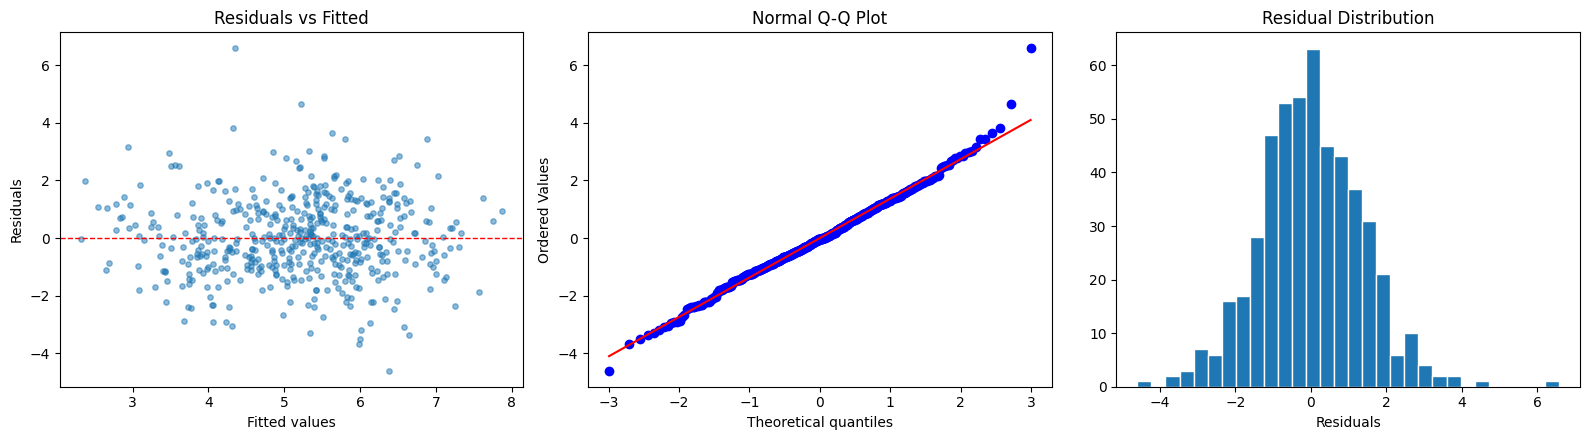

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def residual_diagnostic_plots(model):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Residuals vs Fitted
    axes[0].scatter(model.fittedvalues, model.resid, alpha=0.5, s=15)
    axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Fitted values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title("Residuals vs Fitted")

    # Q-Q plot
    stats.probplot(model.resid, dist="norm", plot=axes[1])
    axes[1].set_title("Normal Q-Q Plot")

    # Histogram
    axes[2].hist(model.resid, bins=30, edgecolor="white")
    axes[2].set_xlabel("Residuals")
    axes[2].set_title("Residual Distribution")

    plt.tight_layout()
    plt.savefig("ols_residual_diagnostics.png", dpi=150)
    plt.show()

residual_diagnostic_plots(ols_model)

### Influence/outlier diagnostics
Cook’s distance is used to identify observations that may have a relatively large influence on the fitted regression model. The 4/n value is used as a reference threshold for identifying observations that warrant further examination.

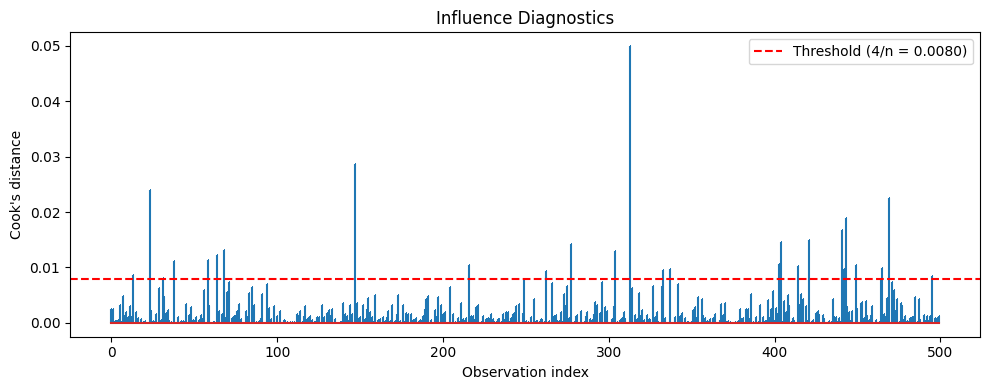

Observations exceeding threshold: 26 / 500


array([2.49471808e-03, 2.45085688e-03, 2.63107827e-04, 3.01942102e-04,
       4.59778953e-04, 3.16768703e-03, 1.06980413e-04, 4.88695064e-03,
       1.41506205e-03, 2.01483782e-03, 1.09414400e-03, 2.98069040e-03,
       1.10825216e-03, 8.61458561e-03, 4.71441098e-06, 1.88457753e-03,
       9.32291541e-04, 9.49207179e-08, 6.41460074e-04, 7.55411587e-05,
       3.60791740e-04, 8.16444012e-06, 6.86724263e-07, 2.38976885e-02,
       2.09794561e-03, 2.99399690e-04, 9.63522150e-05, 1.66873809e-03,
       5.31484438e-06, 6.31792798e-03, 4.80629037e-04, 8.09431453e-03,
       4.60654923e-03, 1.87015878e-03, 2.34872145e-03, 2.74564869e-04,
       1.11387020e-04, 7.06872823e-05, 1.12407671e-02, 7.42354537e-07,
       1.00757871e-03, 4.15195917e-06, 3.14225485e-04, 2.56156194e-04,
       1.46807595e-04, 3.45611232e-03, 1.34703498e-04, 1.44290356e-03,
       2.79949534e-03, 4.63058183e-04, 2.90828766e-04, 1.09045500e-03,
       1.57800230e-06, 5.92642260e-04, 1.39558341e-03, 8.75184233e-04,
      

In [ ]:
def cooks_distance_plot(model):
    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]

    plt.figure(figsize=(10, 4))
    plt.stem(range(len(cooks_d)), cooks_d, markerfmt=",")
    threshold = 4 / len(cooks_d)
    plt.axhline(threshold, color="red", linestyle="--", label=f"Threshold (4/n = {threshold:.4f})")
    plt.xlabel("Observation index")
    plt.ylabel("Cook's distance")
    plt.title("Influence Diagnostics")
    plt.legend()
    plt.tight_layout()
    plt.savefig("cooks_distance.png", dpi=150)
    plt.show()

    n_influential = (cooks_d > threshold).sum()
    print(f"Observations exceeding threshold: {n_influential} / {len(cooks_d)}")
    return cooks_d

cooks_d = cooks_distance_plot(ols_model)

Using the 4/n reference threshold of 0.008, 26 of the 500 observations exceed the threshold. These observations are therefore flagged as potentially influential, although exceeding the threshold does not by itself mean that an observation should be removed.

### OLS specification comparison

In [ ]:
def nested_model_comparison(reg_df):
    m1 = smf.ols("log_commits_per_year ~ github_actions_enabled", data=reg_df).fit(cov_type="HC1")
    m2 = smf.ols("log_commits_per_year ~ github_actions_enabled + repo_age_years + log_stars + log_forks", data=reg_df).fit(cov_type="HC1")
    m3 = smf.ols("log_commits_per_year ~ github_actions_enabled + repo_age_years + log_stars + log_forks + C(language)", data=reg_df).fit(cov_type="HC1")

    comparison = pd.DataFrame({
        "Model 1 (bivariate)": [m1.params["github_actions_enabled"], m1.pvalues["github_actions_enabled"], m1.rsquared],
        "Model 2 (+ covariates)": [m2.params["github_actions_enabled"], m2.pvalues["github_actions_enabled"], m2.rsquared],
        "Model 3 (+ language, full)": [m3.params["github_actions_enabled"], m3.pvalues["github_actions_enabled"], m3.rsquared],
    }, index=["Coefficient", "p-value", "R-squared"])

    print(comparison.round(4))
    comparison.to_csv("nested_model_comparison.csv")
    return comparison

nested_model_comparison(ols_reg_df)

             Model 1 (bivariate)  Model 2 (+ covariates)  \
Coefficient               1.7078                  1.7028   
p-value                   0.0000                  0.0000   
R-squared                 0.1901                  0.3338   

             Model 3 (+ language, full)  
Coefficient                      1.5915  
p-value                          0.0000  
R-squared                        0.3749  


,Model 1 (bivariate),Model 2 (+ covariates),"Model 3 (+ language, full)"
Coefficient,1.707831e+00,1.702762e+00,1.591491e+00
p-value,5.122522e-24,6.952485e-26,6.239381e-22
R-squared,1.901053e-01,3.338059e-01,3.748970e-01


In [ ]:
# Reload the treatment-date file using only the required columns
eligible_treated_raw = pd.read_csv("eligible_treated_repos.csv")

base_cols = ["repo_full_name", "adoption_date", "status", "created_at",
             "has_post_window", "has_pre_window"]
eligible_treated_raw = eligible_treated_raw[base_cols].copy()

print(eligible_treated_raw.columns.tolist())

# Merge repository metadata once using repository name
candidates = pd.read_csv("candidates_with_current_state.csv")

eligible_treated = eligible_treated_raw.merge(
    candidates[["repo_full_name", "language", "stars", "forks"]],
    on="repo_full_name", how="left"
)

print(eligible_treated.columns.tolist())
print(eligible_treated["language"].isna().sum())

eligible_treated_capped = eligible_treated.sample(n=min(905, len(eligible_treated)), random_state=42).reset_index(drop=True)
print(eligible_treated_capped.columns.tolist())

['repo_full_name', 'adoption_date', 'status', 'created_at', 'has_post_window', 'has_pre_window']
['repo_full_name', 'adoption_date', 'status', 'created_at', 'has_post_window', 'has_pre_window', 'language', 'stars', 'forks']
0
['repo_full_name', 'adoption_date', 'status', 'created_at', 'has_post_window', 'has_pre_window', 'language', 'stars', 'forks']


### 10 Technique 2 - Matching/PSM
Technique 2 applies two matching procedures. First, a custom distance-based approach matches repositories using programming language, pre-treatment commit activity, repository age, stars, and forks. Second, propensity-score matching is implemented using PsmPy. Both approaches aim to construct more comparable treated and control groups using pre-treatment information.

### 2.1 Custom Distance-Based Matching

This type of matching process utilizes Euclidean distance after standardization, along with language matching and covariate thresholds prior to treatment. It is therefore referred to as custom distance matching.

In [ ]:
import os
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm

# =METADATA-BASED CANDIDATE SHORTLIST

def build_metadata_shortlist(treated_df, control_pool_df, top_k=5):
    treated_df = treated_df.copy()
    treated_df["adoption_date"] = pd.to_datetime(treated_df["adoption_date"], utc=True)
    treated_df["adoption_month"] = treated_df["adoption_date"].dt.to_period("M").dt.to_timestamp()

    control_pool_df = control_pool_df[control_pool_df["github_actions_enabled"] == 0].copy()
    control_pool_df["created_at"] = pd.to_datetime(control_pool_df["created_at"], utc=True, errors="coerce")

    edges = []
    for language, treated_group in treated_df.groupby("language"):
        controls = control_pool_df[control_pool_df["language"] == language].copy()
        if controls.empty:
            continue

        controls["log_stars"] = np.log1p(controls["stars"])
        controls["log_forks"] = np.log1p(controls["forks"])
        treated_group = treated_group.copy()
        treated_group["log_stars"] = np.log1p(treated_group["stars"])
        treated_group["log_forks"] = np.log1p(treated_group["forks"])

        scaler = StandardScaler()
        control_scaled = scaler.fit_transform(controls[["log_stars", "log_forks"]])
        treated_scaled = scaler.transform(treated_group[["log_stars", "log_forks"]])

        nn = NearestNeighbors(n_neighbors=min(top_k, len(controls)), metric="euclidean")
        nn.fit(control_scaled)
        distances, indices = nn.kneighbors(treated_scaled)

        for row_pos, (_, treated_row) in enumerate(treated_group.iterrows()):
            for rank in range(indices.shape[1]):
                control_row = controls.iloc[indices[row_pos, rank]]
                edges.append({
                    "treated_repo": treated_row["repo_full_name"],
                    "control_repo": control_row["repo_full_name"],
                    "language": language,
                    "adoption_date": treated_row["adoption_date"],
                    "adoption_month": treated_row["adoption_month"],
                    "treated_created_at": treated_row["created_at"],
                    "control_created_at": control_row["created_at"],
                    "metadata_distance": float(distances[row_pos, rank]),
                })

    return pd.DataFrame(edges)



#PRE-TREATMENT COMMIT ACTIVITY

def _get_commit_count_in_window(repo_full_name, headers, since_iso, until_iso):
    url = f"https://api.github.com/repos/{repo_full_name}/commits"
    resp = gh_get(url, headers, params={"since": since_iso, "until": until_iso, "per_page": 1})
    if resp is None or resp.status_code != 200:
        return np.nan
    last_page = get_last_page_num(resp.headers.get("Link"))
    if last_page:
        return last_page
    data = resp.json()
    return len(data) if isinstance(data, list) else np.nan


def _fetch_pre_commits(args):
    repo_name, index_month, headers, window_months = args
    idx = pd.Timestamp(index_month)
    start = idx - pd.DateOffset(months=window_months)
    count = _get_commit_count_in_window(
        repo_name, headers,
        since_iso=pd.Timestamp(start, tz="UTC").isoformat(),
        until_iso=pd.Timestamp(idx, tz="UTC").isoformat(),
    )
    return (repo_name, str(idx.date())), count


def fetch_pretreatment_commit_counts_concurrent(edges_df, headers, window_months=12, max_workers=15,checkpoint_path="pre_commit_counts_checkpoint.csv"):
    results = {}
    if os.path.exists(checkpoint_path):
        saved = pd.read_csv(checkpoint_path)
        for _, row in saved.iterrows():
            results[(row["repo_name"], row["index_month"])] = row["commit_count"]
        print(f"Resuming: {len(results)} already fetched")

    unique_keys = set()
    for _, row in edges_df.iterrows():
        unique_keys.add((row["treated_repo"], row["adoption_month"]))
        unique_keys.add((row["control_repo"], row["adoption_month"]))

    remaining_keys = [
        (repo, month) for repo, month in unique_keys
        if (repo, str(pd.Timestamp(month).date())) not in results
    ]
    print(f"Remaining to fetch: {len(remaining_keys)} / {len(unique_keys)}")

    jobs = [(repo, month, headers, window_months) for repo, month in remaining_keys]

    write_lock = __import__("threading").Lock()

    def _process_and_save(job):
        key, count = _fetch_pre_commits(job)
        with write_lock:
            row = {"repo_name": key[0], "index_month": key[1], "commit_count": count}
            pd.DataFrame([row]).to_csv(checkpoint_path, mode="a",
                                        header=not os.path.exists(checkpoint_path), index=False)
        return key, count

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_process_and_save, job): job for job in jobs}
        for f in tqdm(as_completed(futures), total=len(futures), desc="Fetching pre-treatment commit counts"):
            key, count = f.result()
            results[key] = count

    return results


# REFINED DISTANCE AND 1-TO-1 MATCHIN Candidate pairs must satisfy separate thresholds for pre-treatment activity and repository age before the combined standardized distance is calculated.

def refine_and_match(edges_df, pre_commit_counts, window_months=12, caliper=0.5,max_diff_log_commits=0.7, max_diff_age_days=400):
    df = edges_df.copy()

    df["treated_pre_commits"] = df.apply(lambda r: pre_commit_counts.get((r["treated_repo"], str(pd.Timestamp(r["adoption_month"]).date()))), axis=1)
    df["control_pre_commits"] = df.apply(lambda r: pre_commit_counts.get((r["control_repo"], str(pd.Timestamp(r["adoption_month"]).date()))), axis=1)

    df["treated_created_at"] = pd.to_datetime(df["treated_created_at"], utc=True, errors="coerce").dt.tz_localize(None)
    df["control_created_at"] = pd.to_datetime(df["control_created_at"], utc=True, errors="coerce").dt.tz_localize(None)
    df["treated_age_at_index_days"] = (df["adoption_month"] - df["treated_created_at"]).dt.days
    df["control_age_at_index_days"] = (df["adoption_month"] - df["control_created_at"]).dt.days

    df = df.dropna(subset=["treated_pre_commits", "control_pre_commits","treated_age_at_index_days", "control_age_at_index_days"]).copy()

    df = df[(df["treated_pre_commits"] >= 3) & (df["control_pre_commits"] >= 3)].copy()

    df["diff_log_pre_commits"] = np.abs(np.log1p(df["treated_pre_commits"]) - np.log1p(df["control_pre_commits"]))
    df["diff_age_days"] = np.abs(df["treated_age_at_index_days"] - df["control_age_at_index_days"])

    # Apply covariate-specific thresholds before calculating the combined distance
    df = df[
        (df["diff_log_pre_commits"] <= max_diff_log_commits) &
        (df["diff_age_days"] <= max_diff_age_days)
    ].copy()

    scaler = StandardScaler(with_mean=False)
    scaled = scaler.fit_transform(df[["diff_log_pre_commits", "diff_age_days"]])
    df["refined_distance"] = np.sqrt((scaled ** 2).sum(axis=1))

    df = df.sort_values(["refined_distance", "metadata_distance"]).reset_index(drop=True)

    used_treated, used_control = set(), set()
    matched_rows = []
    for _, row in df.iterrows():
        if row["treated_repo"] in used_treated or row["control_repo"] in used_control:
            continue
        if row["refined_distance"] > caliper:
            continue
        matched_rows.append(row)
        used_treated.add(row["treated_repo"])
        used_control.add(row["control_repo"])

    matched_pairs = pd.DataFrame(matched_rows).reset_index(drop=True)
    print(f"Final matched pairs (pre-treatment matched): {len(matched_pairs)}")
    print(f"  from {edges_df['treated_repo'].nunique()} candidate treated repos")
    return matched_pairs


#COVARIATE BALANCE CHECK

def balance_check_pretreatment(matched_pairs):
    rows = []
    for label, t_col, c_col in [
        ("Pre-treatment commits (log)",
         np.log1p(matched_pairs["treated_pre_commits"]), np.log1p(matched_pairs["control_pre_commits"])),
        ("Repo age at adoption (days)",
         matched_pairs["treated_age_at_index_days"], matched_pairs["control_age_at_index_days"]),
    ]:
        pooled_sd = np.sqrt((t_col.var() + c_col.var()) / 2)
        smd = (t_col.mean() - c_col.mean()) / pooled_sd if pooled_sd > 0 else np.nan
        rows.append({
            "covariate": label,
            "treated_mean": t_col.mean(),
            "control_mean": c_col.mean(),
            "std_mean_diff": smd,
        })
    balance_df = pd.DataFrame(rows)
    print(balance_df)
    print("\nRule of thumb: |std_mean_diff| < 0.1 indicates good balance.")
    return balance_df


metadata_edges  =  build_metadata_shortlist(eligible_treated_capped, candidates, top_k=5)
print(f"Candidate edges from metadata shortlist: {len(metadata_edges)}")

pre_commit_counts = fetch_pretreatment_commit_counts_concurrent(metadata_edges, HEADERS, window_months=12)

matched_pairs_distance = refine_and_match(metadata_edges, pre_commit_counts, window_months=12,caliper=10.0, max_diff_log_commits=0.8, max_diff_age_days=500)
balance_df = balance_check_pretreatment(matched_pairs_distance)

matched_pairs_distance.to_csv("matched_pairs_distance_based.csv", index=False)
print(f"Final: {len(matched_pairs_distance)} pairs")

/tmp/ipykernel_2002/4188859527.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  treated_df["adoption_month"] = treated_df["adoption_date"].dt.to_period("M").dt.to_timestamp()


Candidate edges from metadata shortlist: 4520
Remaining to fetch: 4815 / 4815


Fetching pre-treatment commit counts:   0%|          | 0/4815 [00:00<?, ?it/s]

Final matched pairs (pre-treatment matched): 97
  from 904 candidate treated repos
                     covariate  treated_mean  control_mean  std_mean_diff
0  Pre-treatment commits (log)      4.363588      4.337871       0.018617
1  Repo age at adoption (days)   1841.350515   1782.742268       0.054979

Rule of thumb: |std_mean_diff| < 0.1 indicates good balance.
Final: 97 pairs


### 2.2 Propensity Score Matching with PsmPy

Repositiories treated for GitHub Actions use the GitHub Actions adoption month for that repository as their reference month. As there is no adoption month for repositories that do not adopt, each control repository is given a unique reference month chosen from among the possible adoption months of the treated repositories within the same programming language.

In [ ]:
!pip install psmpy -q

In [ ]:
import os
import numpy as np
import pandas as pd

from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from psmpy import PsmPy

#### Prepare reference months for treated repositories

With respect to treated repositories, the reference month refers to the month when GitHub Actions were introduced. This month is the time frame that will be used for determining the age of the repository as well as pre-treatment activity.

In [ ]:
def prepare_treated_index_dates(eligible_treated_capped):
    treated = eligible_treated_capped.copy()
    treated["adoption_date"] = pd.to_datetime(treated["adoption_date"], utc=True,errors="coerce")
    treated["created_at"] = pd.to_datetime(treated["created_at"],utc=True,errors="coerce")
    # Month in which GitHub Actions was adopted
    treated["reference_month"] = (treated["adoption_date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp())
    treated = treated.dropna(subset=["reference_month", "created_at", "language"]).copy()
    return treated

#### Assign reference months to control repositories

Control repositories have no actual GitHub Actions adoption date. Therefore, every control repository gets only one treated month when its programming language has an eligible adoption month. In order to ensure that the entire pre-treatment period was covered, the control had to be there for 12 months before the assigned month.

In [ ]:
def assign_control_reference_months(candidates, treated_index_df, pre_window_months=12, seed=42):
    rng = np.random.default_rng(seed)
    controls = candidates[candidates["github_actions_enabled"] == 0][["repo_full_name", "language", "stars", "forks", "created_at"]].copy()
    controls["created_at"] = pd.to_datetime(controls["created_at"], utc=True, errors="coerce")
    # Store eligible treated adoption months separately for each programming language
    months_by_language = {
        language: group["reference_month"].dropna().unique()
        for language, group in treated_index_df.groupby("language")
    }

    assigned_rows = []

    for _, row in controls.iterrows():
        language = row["language"]

        if language not in months_by_language:
            continue

        possible_months = pd.to_datetime(months_by_language[language])
        created = row["created_at"]

        if pd.isna(created):
            continue

        # Require at least 12 months of repository history before the reference month
        minimum_reference_month = created.tz_localize(None) + pd.DateOffset(months=pre_window_months)
        valid_months = possible_months[possible_months >= minimum_reference_month]

        if len(valid_months) == 0:
            continue

        reference_month = pd.Timestamp(rng.choice(valid_months))

        assigned_rows.append({
            "repo_full_name": row["repo_full_name"],
            "language": language,
            "stars": row["stars"],
            "forks": row["forks"],
            "created_at": created,
            "reference_month": reference_month
        })

    control_index_df = pd.DataFrame(assigned_rows)

    print(f"Controls with valid pseudo-index month: {len(control_index_df)}")

    return control_index_df

#### Collect 12-month pre-treatment commit activity for controls

The commit count for 12 months preceding the reference month for each control repository is computed. The 12-month commit count serves as the pre-intervention measure used in the analysis of the propensity score matching model.

Since it involves requests from GitHub API, the output is saved in the checkpoint file so as to continue collecting data without reissuing the already executed requests.

In [ ]:
def fetch_control_precommits(control_index_df,headers,window_months=12,max_workers=10,checkpoint_path="psmpy_control_precommits.csv"):
    results = {}
    # Resume from an existing checkpoint
    if os.path.exists(checkpoint_path):
        saved = pd.read_csv(checkpoint_path)
        for _, row in saved.iterrows():
            key = (row["repo_full_name"], row["reference_month"])
            results[key] = row["pre_commits"]
        print(f"Loaded {len(results)} PSM control pre-treatment counts from checkpoint.")
    jobs = []
    for _, row in control_index_df.iterrows():
        repo = row["repo_full_name"]
        reference_month = pd.Timestamp(row["reference_month"])
        reference_string = str(reference_month.date())
        key = (repo, reference_string)
        if key in results:
            continue
        jobs.append((repo, reference_month))
    print(f"Control pre-treatment commit fetches required: {len(jobs)}")
    def fetch_one(job):
        repo, reference_month = job
        start = reference_month - pd.DateOffset(months=window_months)
        count = _get_commit_count_in_window(repo,headers,
            since_iso=pd.Timestamp(start, tz="UTC").isoformat(),
            until_iso=pd.Timestamp(reference_month, tz="UTC").isoformat()
        )

        return repo, str(reference_month.date()), count
    rows_to_save = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(fetch_one, job) for job in jobs]
        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Fetching PSM control pre-treatment commits"
        ):
            repo, month, count = future.result()
            results[(repo, month)] = count
            rows_to_save.append({
                "repo_full_name": repo,
                "reference_month": month,
                "pre_commits": count
            })
            # Saves progress periodically during API collection
            if len(rows_to_save) >= 25:
                pd.DataFrame(rows_to_save).to_csv(
                    checkpoint_path,
                    mode="a",
                    header=not os.path.exists(checkpoint_path),
                    index=False
                )
                rows_to_save = []

    # Saves any observations remaining after the final checkpoint
    if rows_to_save:
        pd.DataFrame(rows_to_save).to_csv(
            checkpoint_path,
            mode="a",
            header=not os.path.exists(checkpoint_path),
            index=False
        )

    return results

#### Build the repository-level PSM dataset

One observation is created for each repository. Pre-treatment commits and repository age are measured relative to the repository's reference month. Commit activity, stars and forks are log-transformed because these variables are highly skewed, while programming language is represented using indicator variables.

In [ ]:
def build_psmpy_unit_dataframe(treated_index_df,control_index_df,treated_pre_commit_counts,control_pre_commit_counts):
    treated = treated_index_df.copy()
    # Retrieve treated repositories' pre-treatment commit counts
    treated["pre_commits"] = treated.apply(
        lambda row: treated_pre_commit_counts.get(
            (row["repo_full_name"], str(pd.Timestamp(row["reference_month"]).date()))
        ),
        axis=1
    )
    treated["age_at_index_days"] = (treated["reference_month"] - treated["created_at"].dt.tz_localize(None)).dt.days
    treated["treatment"] = 1
    controls = control_index_df.copy()
    # Retrieve control repositories' pre-treatment commit counts
    controls["pre_commits"] = controls.apply(
        lambda row: control_pre_commit_counts.get(
            (row["repo_full_name"], str(pd.Timestamp(row["reference_month"]).date()))
        ),
        axis=1
    )
    controls["age_at_index_days"] = (controls["reference_month"] - controls["created_at"].dt.tz_localize(None)).dt.days
    controls["treatment"] = 0
    keep_cols = ["repo_full_name","language","stars","forks","reference_month","pre_commits","age_at_index_days","treatment"]
    unit_df = pd.concat([treated[keep_cols], controls[keep_cols]], ignore_index=True)
    # Remove repositories without the required pre-treatment information
    unit_df = unit_df.dropna(subset=["pre_commits", "age_at_index_days", "language"]).copy()
    unit_df = unit_df[(unit_df["pre_commits"] >= 0) & (unit_df["age_at_index_days"] > 0) ].copy()

    unit_df["log_pre_commits"] = np.log1p(unit_df["pre_commits"])
    unit_df["log_stars"] = np.log1p(unit_df["stars"].clip(lower=0))
    unit_df["log_forks"] = np.log1p(unit_df["forks"].clip(lower=0))

    # Convert programming language into indicator variables
    unit_df = pd.get_dummies(unit_df,columns=["language"],prefix="lang",drop_first=True,dtype=int)

    # Confirm that each repository appears only once
    assert unit_df["repo_full_name"].is_unique

    return unit_df.reset_index(drop=True)

#### Estimate propensity scores and perform matching

Propensity score model is used to predict the probability of GitHub Actions adoption based on log pre-treatment commit frequency, age of repository, and programming language. The treated observations are paired with control observations at a 1:1 ratio through the propensity score logit function using a caliper value of 0.25 with matching without replacement. Stars and forks variables are excluded from the propensity score model but are kept for balance tests after matching.

In [ ]:
def run_psmpy_matching(unit_df, caliper=0.25):
    language_cols = [col for col in unit_df.columns if col.startswith("lang_")]
    # Variables included in the propensity-score model
    model_cols = ["log_pre_commits", "age_at_index_days"] + language_cols
    psm_input = unit_df[["repo_full_name", "treatment"] + model_cols].copy()
    psm_input["treatment"] = psm_input["treatment"].astype(int)
    for col in model_cols:
        psm_input[col] = psm_input[col].astype(float)
    psm = PsmPy( psm_input,treatment="treatment",indx="repo_full_name",exclude=[])
    psm.logistic_ps(balance=True)
    psm.kdtree_matched(
        matcher="propensity_logit",
        replacement=False,
        caliper=caliper
    )
    print(f"Matched treated repositories: {len(psm.matched_ids)}")
    return psm

#### Construct the treated-control pair table

The outputs of PsmPy are converted to the clear form of table of treated and control pairs. For each treated repository, both observed time of adoption and reference month are retained to be used in further analysis.

In [ ]:
def build_psmpy_pairs(psm, treated_index_df):
    matched = psm.matched_ids.copy()
    matched.columns = ["repo_full_name", "matched_ID"]
    treatment_map = (psm.predicted_data.set_index(psm.indx)[psm.treatment].to_dict())
    matched["repo_is_treated"] = matched["repo_full_name"].map(treatment_map)
    matched["treated_repo"] = np.where(matched["repo_is_treated"] == 1,matched["repo_full_name"],matched["matched_ID"])
    matched["control_repo"] = np.where(matched["repo_is_treated"] == 1,matched["matched_ID"],matched["repo_full_name"])
    pairs = matched[["treated_repo", "control_repo"]].drop_duplicates().reset_index(drop=True)
    pairs = pairs.merge( treated_index_df[["repo_full_name", "adoption_date", "reference_month"]],
        left_on="treated_repo",
        right_on="repo_full_name",
        how="left"
    )
    pairs = pairs.drop(columns=["repo_full_name"])
    return pairs

#### Assess post-matching covariate balance

The SMDs are calculated after matching, to measure the extent of the similarity between the treated and the control repositories. The smaller the absolute value of SMDs, the better the balance. An absolute value of SMD below 0.10 is taken as the general guiding principle for balance.

The balance is measured based on the commit activities before treatment, repository age, and the star and fork metrics. Stars and forks are included here as additional diagnostics even though they were not included in the propensity-score model.

In [ ]:
def check_psmpy_balance(matched_pairs, unit_df):
    lookup = unit_df.set_index("repo_full_name")
    treated_names = matched_pairs["treated_repo"].tolist()
    control_names = matched_pairs["control_repo"].tolist()
    treated_matched = lookup.loc[treated_names]
    control_matched = lookup.loc[control_names]
    covariates = [
        "log_pre_commits",
        "age_at_index_days",
        "log_stars",
        "log_forks"
    ]

    rows = []
    for col in covariates:
        t = treated_matched[col].astype(float)
        c = control_matched[col].astype(float)
        pooled_sd = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
        smd = ((t.mean() - c.mean()) / pooled_sd if pooled_sd > 0 else np.nan)

        rows.append({
            "covariate": col,
            "treated_mean": t.mean(),
            "control_mean": c.mean(),
            "std_mean_diff": smd,
            "abs_smd": abs(smd)
        })

    balance_df = pd.DataFrame(rows)

    print("\nPost-matching covariate balance:")
    print(balance_df)
    print("\nRule of thumb: |SMD| < 0.10 indicates good balance.")

    return balance_df

In [ ]:
# Prepare actual reference months for treated repositories
treated_index_psm = prepare_treated_index_dates(eligible_treated_capped)
print(f"Treated repositories available for PSM: {len(treated_index_psm)}")
# Assign reference months to never-treated controls
control_index_psm = assign_control_reference_months( candidates,treated_index_psm,pre_window_months=12,seed=42)
# Collect 12-month pre-treatment commit activity for controls
control_pre_commit_counts_psm = fetch_control_precommits(control_index_psm,HEADERS,window_months=12,max_workers=10,checkpoint_path="psmpy_control_precommits.csv")
# Build the repository-level PSM dataset
unit_df = build_psmpy_unit_dataframe(
    treated_index_df=treated_index_psm,
    control_index_df=control_index_psm,
    treated_pre_commit_counts=pre_commit_counts,
    control_pre_commit_counts=control_pre_commit_counts_psm
)
print(f"\nPSM dataset: {len(unit_df)} repositories")
print(f"Treated: {(unit_df['treatment'] == 1).sum()}")
print(f"Controls: {(unit_df['treatment'] == 0).sum()}")

# Estimate propensity scores and perform matching
psm_model = run_psmpy_matching(unit_df,caliper=0.25)

# Construct the final matched-pair table
matched_pairs_psmpy = build_psmpy_pairs(psm_model,treated_index_psm)
print(f"\nFinal PsmPy matched pairs: {len(matched_pairs_psmpy)}")

# Assess covariate balance after matching
balance_psmpy = check_psmpy_balance(matched_pairs_psmpy,unit_df)

# Save the matched pairs and balance results
matched_pairs_psmpy.to_csv("psm_matched_pairs_psmpy.csv",index=False)
balance_psmpy.to_csv("psmpy_balance.csv",index=False)
matched_pairs_psmpy.head()

Treated repositories available for PSM: 904
Controls with valid pseudo-index month: 527
Loaded 125 PSM control pre-treatment counts from checkpoint.
Control pre-treatment commit fetches required: 402
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s
[rate limiter] 41 left, sleeping 437s


Fetching PSM control pre-treatment commits:   0%|          | 0/402 [00:00<?, ?it/s]


PSM dataset: 1431 repositories
Treated: 904
Controls: 527
Matched treated repositories: 313

Final PsmPy matched pairs: 313

Post-matching covariate balance:
           covariate  treated_mean  control_mean  std_mean_diff   abs_smd
0    log_pre_commits      3.411224      3.438491      -0.013227  0.013227
1  age_at_index_days   2158.335463   2075.447284       0.069199  0.069199
2          log_stars      8.739782      8.603998       0.145340  0.145340
3          log_forks      6.513875      6.451930       0.047861  0.047861

Rule of thumb: |SMD| < 0.10 indicates good balance.


/usr/local/lib/python3.13/dist-packages/psmpy/psmpy.py:374: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False')


,treated_repo,control_repo,adoption_date,reference_month
0,getsops/sops,jagenjo/litegraph.js,2021-01-05 00:00:00+00:00,2021-01-01
1,google/recaptcha,zhaoolee/ChromeAppHeroes,2023-02-20 00:00:00+00:00,2023-02-01
2,PaddlePaddle/PaddleOCR,jondot/awesome-react-native,2024-03-27 00:00:00+00:00,2024-03-01
3,Foso/Ktorfit,jwise/HoRNDIS,2022-04-13 00:00:00+00:00,2022-04-01
4,w4po/ExplorerTabUtility,AndroidCoderPeng/DailyTask,2025-01-27 00:00:00+00:00,2025-01-01


#### PSM matching result

PSM sample consisted of 1,431 repositories, of which 904 were treated and 527 were matched controls. After 1:1 caliper matching without replacement, 318 treated repositories could be matched to control repositories.


#### Compare the two matching procedures

The custom distance-based and PsmPy matching procedures may select different treated repositories and different controls. Their matched samples are therefore compared to examine the amount of overlap between the two approaches.

In [ ]:
matched_pairs_distance = pd.read_csv("matched_pairs_distance_based.csv")

In [ ]:
import pandas as pd

matched_pairs_distance = pd.read_csv("matched_pairs_distance_based.csv")
matched_pairs_psmpy = matched_pairs_psmpy.copy()

# Compare matched-sample sizes
print(f"Distance-based: {len(matched_pairs_distance)} pairs")
print(f"PsmPy: {len(matched_pairs_psmpy)} pairs")

# Compare exact treated-control pair assignments
distance_pairs = set(zip(matched_pairs_distance["treated_repo"], matched_pairs_distance["control_repo"]))
psmpy_pairs = set(zip(matched_pairs_psmpy["treated_repo"], matched_pairs_psmpy["control_repo"]))
print(f"Identical treated-control pairs: {len(distance_pairs & psmpy_pairs)}")

# Compare overlap in treated repositories
distance_treated = set(matched_pairs_distance["treated_repo"])
psmpy_treated = set(matched_pairs_psmpy["treated_repo"])
overlap = distance_treated & psmpy_treated
print(f"Same treated repo appears in both: {len(overlap)} / {len(distance_treated)} "
      f"({len(overlap)/len(distance_treated)*100:.1f}%)")

Distance-based: 97 pairs
PsmPy: 313 pairs
Identical treated-control pairs: 0
Same treated repo appears in both: 41 / 97 (42.3%)


In [ ]:
def check_positivity(psm_object):
    scores = psm_object.predicted_data["propensity_score"]
    extreme_low = (scores < 0.05).sum()
    extreme_high = (scores > 0.95).sum()
    print(f"Propensity score < 0.05: {extreme_low}")
    print(f"Propensity score > 0.95: {extreme_high}")
    print(f"Total extreme: {extreme_low + extreme_high} / {len(scores)} "
          f"({(extreme_low+extreme_high)/len(scores)*100:.1f}%)")

check_positivity(psm_model)

Propensity score < 0.05: 11
Propensity score > 0.95: 40
Total extreme: 51 / 1427 (3.6%)


## 11. Technique 3 - DiD (Difference-in-Differences)
Difference in Differences (DiD) goes beyond matched sample analysis through inclusion of the activity in the repositories both before and after the use of GitHub Actions.

For the treated repositories, the matching done through PsmPy gives out a control repository. The month when the adoption took place in the treated repository is considered the common month index for the two repositories. Monthly commit activity is noted for 12 months before and 12 months after the index month.

The difference in differences measure evaluates the differential change in commit activity between the treated and matched control repositories.


### Collect monthly commit histories

Commit dates are collected from the GitHub API for both the treated and corresponding control repositories. These dates are then used to aggregate monthly commit counts, with the adoption month as the center for the treated repository

In [ ]:
def _fetch_commit_dates(repo_full_name, headers, since_iso, until_iso, max_pages=50):
    url = f"https://api.github.com/repos/{repo_full_name}/commits"
    dates = []
    page = 1
    while page <= max_pages:
        resp = gh_get(url, headers, params={"since": since_iso, "until": until_iso, "per_page": 100, "page": page})
        if resp is None or resp.status_code != 200:
            return dates, "error" if resp is None else f"http_{resp.status_code}"
        records = resp.json()

        if not isinstance(records, list) or not records:
            break
        for rec in records:
            commit = rec.get("commit", {})
            date_val = (commit.get("committer") or {}).get("date") or (commit.get("author") or {}).get("date")
            if date_val:
                dates.append(date_val)
        if len(records) < 100:
            break
        page += 1
    return dates, "ok"


### Construct the monthly event-time panel

Monthly commits per repository are computed for a period of 12 months before and 12 months after the index month.

Eventnth is _moa measure of how many months away it is from adoption, with a negative sign representing the pre-treatment period and a positive sign representing the post-treatment period. The adoption month starts off with event_month = 0 and is later eliminated from the panel data.

The interaction term of the difference-in-differences model equals 1 only for treated repositories in the post-treatment period.

In [ ]:
def _build_monthly_panel(commit_dates, repo_name, index_month, treated, pair_id, window_months):
    index_month = pd.Timestamp(index_month).to_period("M").to_timestamp()
    months = pd.date_range(
        start=index_month - pd.DateOffset(months=window_months),
        end=index_month + pd.DateOffset(months=window_months),
        freq="MS",
    )
    monthly = pd.DataFrame({"month": months})

    if commit_dates:
        cdf = pd.DataFrame({"commit_date": pd.to_datetime(commit_dates, utc=True, errors="coerce")}).dropna()
        cdf["month"] = cdf["commit_date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
        counts = cdf.groupby("month").size().reset_index(name="commits")
        monthly = monthly.merge(counts, on="month", how="left")
    else:
        monthly["commits"] = np.nan

    monthly["commits"] = monthly["commits"].fillna(0).astype(int)
    monthly["repo_name"] = repo_name
    monthly["pair_id"] = pair_id
    monthly["treated"] = treated
    monthly["index_month"] = index_month
    monthly["event_month"] = (
        (monthly["month"].dt.year - index_month.year) * 12 + monthly["month"].dt.month - index_month.month
    )
    monthly["post"] = (monthly["event_month"] >= 1).astype(int)
    monthly["did"] = monthly["treated"] * monthly["post"]
    return monthly


### Retrieve the repository panels

A history per month is built for each control-treatment pair. Both the repositories are assigned the same treated adoption month, thus ensuring that they are evaluated over the same period of time.

Duplication of repository and window pairs is not allowed, and an interim dataset can be maintained as part of the API retrieval process.

In [ ]:
def _fetch_one(args):
    repo_name, index_month, treated, pair_id, headers, window_months = args

    idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
    start = idx - pd.DateOffset(months=window_months)
    end = idx + pd.DateOffset(months=window_months + 1)

    dates, status = _fetch_commit_dates(repo_name,headers,
        since_iso=pd.Timestamp(start, tz="UTC").isoformat(),
        until_iso=pd.Timestamp(end, tz="UTC").isoformat()
    )

    panel = _build_monthly_panel(dates, repo_name,idx,treated,pair_id,window_months)

    return pair_id, repo_name, treated, panel, status

In [ ]:
def fetch_did_panel_concurrent(matched_pairs_df,adoption_dates_df,headers,window_months=12,max_workers=10,checkpoint_path=None,checkpoint_every=20):
    adoption_map = dict(zip(adoption_dates_df["repo_full_name"], adoption_dates_df["adoption_date"]))
    jobs = []
    seen = {}
    for pid, row in matched_pairs_df.reset_index(drop=True).iterrows():
        treated_repo = row["treated_repo"]
        control_repo = row["control_repo"]
        idx_month = adoption_map.get(treated_repo)
        if pd.isna(idx_month):
            continue
        for repo_name, treated_flag in [(treated_repo, 1), (control_repo, 0)]:
            key = (repo_name, idx_month)
            if key not in seen:
                seen[key] = True
                jobs.append((repo_name, idx_month, treated_flag, pid, headers, window_months))
    print(f"Repo-window fetches needed (deduplicated): {len(jobs)}")
    results = []
    errors = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_fetch_one, job): job for job in jobs}
        for i, f in enumerate(tqdm(as_completed(futures), total=len(futures), desc="Fetching DiD panels"),1):
            job = futures[f]
            try:
                pair_id, repo_name, treated, panel, status = f.result()
                if status != "ok":
                    errors.append({"pair_id": pair_id, "repo_name": repo_name, "status": status})
                results.append(panel)
            except Exception as exc:
                errors.append({"pair_id": job[3],"repo_name": job[0],"status": f"exception: {exc}"})

            # Save intermediate panel data during long API collection
            if checkpoint_path and i % checkpoint_every == 0:
                pd.concat(results, ignore_index=True).to_csv(checkpoint_path, index=False)
    panel_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
    if checkpoint_path:
        panel_df.to_csv(checkpoint_path, index=False)
    return panel_df, pd.DataFrame(errors)

### Clean the DiD panel

The adoption month (event month 0) is excluded so that the analysis contains 12 complete pre-treatment months and 12 complete post-treatment months.

Only repositories with all 24 required monthly observations are retained, and both repositories in each treated-control pair must be present.

In [ ]:
def clean_did_panel(panel_df, window_months=12):
    panel_df = panel_df[panel_df["event_month"] != 0].copy()

    counts = panel_df.groupby(["pair_id", "repo_name", "treated"]).size().reset_index(name="n")
    expected = window_months * 2
    valid_keys = set(zip(counts.loc[counts["n"] == expected, "pair_id"],
                          counts.loc[counts["n"] == expected, "repo_name"]))

    panel_df["key"] = list(zip(panel_df["pair_id"], panel_df["repo_name"]))
    panel_df = panel_df[panel_df["key"].isin(valid_keys)].drop(columns="key")

    pair_groups = panel_df.groupby("pair_id").agg(reps=("repo_name", "nunique"), grps=("treated", "nunique"))
    complete_pairs = pair_groups[(pair_groups["reps"] == 2) & (pair_groups["grps"] == 2)].index
    panel_df = panel_df[panel_df["pair_id"].isin(complete_pairs)].copy()

    panel_df["log_commits"] = np.log1p(panel_df["commits"])
    print(f"Final: {panel_df['pair_id'].nunique()} complete pairs, {len(panel_df)} observations")
    return panel_df




In [ ]:
def run_did_regression(did_panel):
      did_panel = did_panel.copy()
      did_panel["month"] = pd.to_datetime(did_panel["month"])  # Ensure a datetime index for panel estimation

      reg_panel = did_panel.set_index(["repo_name", "month"]).sort_index()
      model = PanelOLS.from_formula(
          "log_commits ~ 1 + did + EntityEffects + TimeEffects",
          data=reg_panel, drop_absorbed=True,
      )
      result = model.fit(cov_type="clustered", cluster_entity=True)
      print(result.summary)

      beta = float(result.params["did"])
      pval = float(result.pvalues["did"])
      ci = result.conf_int().loc["did"]
      pct_effect = (np.exp(beta) - 1) * 100

      print(f"\nDiD coefficient: {beta:.4f} (p={pval:.4f})")
      print(f"Approx. percentage effect: {pct_effect:.2f}%")
      print(f"95% CI (coefficient): ({float(ci.iloc[0]):.4f}, {float(ci.iloc[1]):.4f})")

      return result


### Build the PsmPy-based DiD panel

The final PsmPy matched pairs are used for the main DiD analysis. For each pair, monthly activity is aligned to the treated repository's GitHub Actions adoption month.

In [ ]:
panel_df_psmpy, collection_errors_psmpy = fetch_did_panel_concurrent(
    matched_pairs_df=matched_pairs_psmpy,
    adoption_dates_df=eligible_treated[["repo_full_name", "adoption_date"]],
    headers=HEADERS,
    window_months=12,
    max_workers=5,
    checkpoint_path="did_panel_checkpoint_psmpy.csv",
)
print("Panel shape:", panel_df_psmpy.shape)
print("Errors:", len(collection_errors_psmpy))

Repo-window fetches needed (deduplicated): 626


/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()


Fetching DiD panels:   0%|          | 0/626 [00:00<?, ?it/s]

/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will

Panel shape: (15650, 9)
Errors: 0


In [ ]:
panel_df_psmpy.to_csv("panel_df_psmpy_FINAL.csv", index=False)

### Retain the complete 24-month analysis panel

The adoption month is removed and the panel is restricted to repositories with 12 pre-treatment and 12 post-treatment monthly observations.

In [ ]:
did_panel_psmpy= clean_did_panel(panel_df_psmpy, window_months=12)
did_panel_psmpy.to_csv("did_panel_psmpy.csv", index=False)
did_panel_psmpy.head()


Final: 313 complete pairs, 15024 observations


,month,commits,repo_name,pair_id,treated,index_month,event_month,post,did,log_commits
0,2022-02-01,1,zhaoolee/ChromeAppHeroes,1,0,2023-02-01,-12,0,0,0.693147
1,2022-03-01,0,zhaoolee/ChromeAppHeroes,1,0,2023-02-01,-11,0,0,0.000000
2,2022-04-01,0,zhaoolee/ChromeAppHeroes,1,0,2023-02-01,-10,0,0,0.000000
3,2022-05-01,3,zhaoolee/ChromeAppHeroes,1,0,2023-02-01,-9,0,0,1.386294
4,2022-06-01,0,zhaoolee/ChromeAppHeroes,1,0,2023-02-01,-8,0,0,0.000000


### Run the DiD regression

In [ ]:
did_result_psmpy = run_did_regression(did_panel_psmpy)

                          PanelOLS Estimation Summary                           
Dep. Variable:            log_commits   R-squared:                        0.0160
Estimator:                   PanelOLS   R-squared (Between):              0.0191
No. Observations:               15024   R-squared (Within):               0.0270
Date:                Mon, Aug 24 2026   R-squared (Overall):              0.0220
Time:                        09:10:39   Log-likelihood                -2.016e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      232.95
Entities:                         626   P-value                           0.0000
Avg Obs:                       24.000   Distribution:                 F(1,14301)
Min Obs:                       24.000                                           
Max Obs:                       24.000   F-statistic (robust):             35.940
                            

### DiD result

In the final DiD model, there are 626 repositories selected from 313 pairs of matching treated and control groups, and the total number of monthly observations is 15024.

The DiD coefficient is 0.4296 (95% confidence interval: 0.28911 to 0.5701; p < 0.001). The exponentiation of the log-transformed coefficient results in an estimated percentage effect of 53.67%.

The positive value of the coefficient suggests that the change in monthly commit frequency after adoption is higher in the treatment group than in the control group. The estimate is causal only under the assumptions made in the DiD model, including the parallel trends assumption.

### DiD using the distance-based matched sample

The model for DiD is also used on the matched sample based on the custom distance to compare it with the main DiD approach implemented with PsmPy.

The panel construction takes place over 12 months before and after the intervention, and the DiD approach with the fixed effects is used.

In [ ]:
panel_df_distance, collection_errors_distance = fetch_did_panel_concurrent(
    matched_pairs_df=matched_pairs_distance,
    adoption_dates_df=eligible_treated[["repo_full_name", "adoption_date"]],
    headers=HEADERS,
    window_months=12,
    max_workers=5,
    checkpoint_path="did_panel_checkpoint_distance.csv",
)
print("Panel shape:", panel_df_distance.shape)

Repo-window fetches needed (deduplicated): 194
[rate limiter] 46 left, sleeping 481s
[rate limiter] 46 left, sleeping 481s
[rate limiter] 46 left, sleeping 481s
[rate limiter] 46 left, sleeping 481s
[rate limiter] 46 left, sleeping 481s


/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()


Fetching DiD panels:   0%|          | 0/194 [00:00<?, ?it/s]

/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will drop timezone information.
  idx = pd.Timestamp(index_month).to_period("M").to_timestamp()
/tmp/ipykernel_2002/4176752276.py:4: UserWarning: Converting to Period representation will

Panel shape: (4850, 9)


In [ ]:
did_panel_distance = clean_did_panel(panel_df_distance, window_months=12)
did_panel_distance.to_csv("did_panel_distance.csv", index=False)
did_panel_distance.head()

Final: 97 complete pairs, 4656 observations


,month,commits,repo_name,pair_id,treated,index_month,event_month,post,did,log_commits
0,2020-07-01,0,geokit/geokit-rails,1,0,2021-07-01,-12,0,0,0.000000
1,2020-08-01,0,geokit/geokit-rails,1,0,2021-07-01,-11,0,0,0.000000
2,2020-09-01,2,geokit/geokit-rails,1,0,2021-07-01,-10,0,0,1.098612
3,2020-10-01,0,geokit/geokit-rails,1,0,2021-07-01,-9,0,0,0.000000
4,2020-11-01,0,geokit/geokit-rails,1,0,2021-07-01,-8,0,0,0.000000


In [ ]:
did_result_distance = run_did_regression(did_panel_distance)


                          PanelOLS Estimation Summary                           
Dep. Variable:            log_commits   R-squared:                        0.0121
Estimator:                   PanelOLS   R-squared (Between):              0.0177
No. Observations:                4656   R-squared (Within):               0.0105
Date:                Mon, Aug 24 2026   R-squared (Overall):              0.0147
Time:                        09:40:54   Log-likelihood                   -6526.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      53.489
Entities:                         194   P-value                           0.0000
Avg Obs:                       24.000   Distribution:                  F(1,4369)
Min Obs:                       24.000                                           
Max Obs:                       24.000   F-statistic (robust):             10.731
                            

The matched sample based on distance method produced a DiD coefficient of 0.3903, representing a 47.75% impact. The significance level was p = 0.0014, and its confidence interval is between 0.1507 and 0.6300.
This provides a secondary comparison with the main PsmPy-based DiD estimate of 0.4688.

### Average Treatment Effect on the Treated for the matched samples

The ATT is calculated independently of each matching method through the use of post-treatment commit activity.

The average post-treatment log commit activity is calculated individually for each of the treated repositories and their corresponding controls in the matched pairs. The difference between the averages is calculated and becomes the effect of the pair, while the ATT is the average of all effects from the matched pairs.

This calculation makes use of the pre-treatment period to make the matches

In [ ]:
import numpy as np
import pandas as pd

def matched_att(did_panel, method_name="Matching"):
    post = did_panel[did_panel["post"] == 1].copy()
    # Mean post-treatment outcome for each repository within each pair
    repo_post_mean = (post.groupby(["pair_id", "treated"])["log_commits"].mean().unstack())
    # Keep only complete treated-control pairs
    repo_post_mean = repo_post_mean.dropna(subset=[0, 1])
    repo_post_mean = repo_post_mean.rename(
        columns={
            0: "control_post_mean",
            1: "treated_post_mean"
        }
    )

    # Pair-specific treatment effect
    repo_post_mean["pair_effect"] = ( repo_post_mean["treated_post_mean"]- repo_post_mean["control_post_mean"])

    # ATT = average effect across treated repositories
    att = repo_post_mean["pair_effect"].mean()

    # Standard error of pair-level treatment effects
    se = (
        repo_post_mean["pair_effect"].std(ddof=1)
        / np.sqrt(len(repo_post_mean))
    )

    # Normal-approximation confidence interval
    ci_low = att - 1.96 * se
    ci_high = att + 1.96 * se

    # Convert log effect to approximate percentage difference
    pct_effect = (np.exp(att) - 1) * 100

    print("=" * 55)
    print(f"{method_name} ATT")
    print("=" * 55)
    print(f"Matched pairs       : {len(repo_post_mean)}")
    print(f"ATT (log scale)     : {att:.4f}")
    print(f"Standard error      : {se:.4f}")
    print(f"95% CI              : ({ci_low:.4f}, {ci_high:.4f})")
    print(f"Approx. % effect    : {pct_effect:.2f}%")

    return {
        "att": att,
        "se": se,
        "ci": (ci_low, ci_high),
        "pct_effect": pct_effect,
        "pair_effects": repo_post_mean
    }

In [ ]:
att_distance = matched_att(
    did_panel_distance,
    method_name="Distance-Based Matching"
)

att_psmpy = matched_att(
    did_panel_psmpy,
    method_name="PsmPy Matching"
)

Distance-Based Matching ATT
Matched pairs       : 97
ATT (log scale)     : 0.5743
Standard error      : 0.1145
95% CI              : (0.3499, 0.7986)
Approx. % effect    : 77.58%
PsmPy Matching ATT
Matched pairs       : 313
ATT (log scale)     : 0.5669
Standard error      : 0.0800
95% CI              : (0.4101, 0.7236)
Approx. % effect    : 76.28%


The PsmPy matched sample produced an ATT of 0.5669, corresponding to an approximate 76.28% post-treatment difference.

The custom distance-based matched sample produced an ATT of 0.5743, corresponding to approximately 77.58%.

These ATT estimates are based on post-treatment differences between matched repositories, whereas the DiD estimates additionally account for changes from the pre-treatment period.

### Placebo permutation test

A placebo permutation test is conducted to provide further robustness for the DiD estimate. In each match, the treatment dummy is randomly relabeled such that one repository out of the two receives the treatment label. Then, the DiD regression is estimated using this relabeled dataset.

This process is repeated 500 times, creating the empirical distribution of DiD coefficients that might have been estimated under the condition of random reassignment of treatment labels to repositories in the matched sample.

Hypothesis (Null): The DiD coefficient is not unusual compared to those derived after the treatment labels were relabeled randomly.

Alternative hypothesis: The DiD coefficient is relatively large compared to what is expected in the case of random reassignment of treatment labels.

Because the original treatment was not randomly assigned, this is interpreted as a placebo robustness diagnostic rather than as proof of causal identification.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

def placebo_permutation_test(did_panel, n_permutations=500, seed=42):
    rng = np.random.default_rng(seed)
    pair_ids = did_panel["pair_id"].unique()

    # Estimate the observed DiD coefficient using the original treatment labels
    observed_panel = did_panel.set_index(["repo_name", "month"]).sort_index()
    observed_model = PanelOLS.from_formula("log_commits ~ 1 + did + EntityEffects + TimeEffects",
                                        data=observed_panel, drop_absorbed=True)
    observed_beta = observed_model.fit(cov_type="clustered", cluster_entity=True).params["did"]
    print(f"Observed DiD coefficient: {observed_beta:.4f}")

    permuted_betas = []

    # Reassign treatment within each matched pair and re-estimate the model
    for i in range(n_permutations):
        panel = did_panel.copy()

        # Randomly select one repository in each pair as placebo-treated
        for pid in pair_ids:
            mask = panel["pair_id"] == pid
            repos_in_pair = panel.loc[mask, "repo_name"].unique()
            if len(repos_in_pair) != 2:
                continue
            placebo_treated_repo = rng.choice(repos_in_pair)
            panel.loc[mask, "treated"] = (panel.loc[mask, "repo_name"] == placebo_treated_repo).astype(int)

        panel["did"] = panel["treated"] * panel["post"]

        try:
            reg_panel = panel.set_index(["repo_name", "month"]).sort_index()
            model = PanelOLS.from_formula("log_commits ~ 1 + did + EntityEffects + TimeEffects",
                                           data=reg_panel, drop_absorbed=True)
            beta = model.fit(cov_type="clustered", cluster_entity=True).params["did"]
            permuted_betas.append(beta)
        except Exception:
            continue

        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{n_permutations} permutations completed")

    permuted_betas = np.array(permuted_betas)

    # Compare the observed coefficient with the permutation distribution
    permutation_p_value = (np.abs(permuted_betas) >= np.abs(observed_beta)).mean()

    print(f"\nPermutation distribution: mean={permuted_betas.mean():.4f}, SD={permuted_betas.std():.4f}")
    print(f"Permutation p-value: {permutation_p_value:.4f}")

    plt.figure(figsize=(9, 5))
    plt.hist(permuted_betas, bins=40, alpha=0.7, edgecolor="white")
    plt.axvline(observed_beta, color="red", linestyle="--", linewidth=2, label=f"Observed = {observed_beta:.3f}")
    plt.xlabel("Permuted DiD coefficient")
    plt.ylabel("Frequency")
    plt.title("Placebo Permutation Distribution")
    plt.legend()
    plt.tight_layout()
    plt.savefig("placebo_test.png", dpi=150)
    plt.show()

    return permuted_betas, permutation_p_value




#### Run the placebo test

The placebo test is applied to the same 318 matched pairs used in the main DiD analysis.

In [ ]:
did_panel_placebo = clean_did_panel(panel_df_psmpy, window_months=12)
print(did_panel_placebo["pair_id"].nunique(), "pairs")

Final: 313 complete pairs, 15024 observations
313 pairs


Observed DiD coefficient: 0.4296
  100/500 permutations completed
  200/500 permutations completed
  300/500 permutations completed
  400/500 permutations completed
  500/500 permutations completed

Permutation distribution: mean=0.1007, SD=0.0658
Permutation p-value: 0.0000


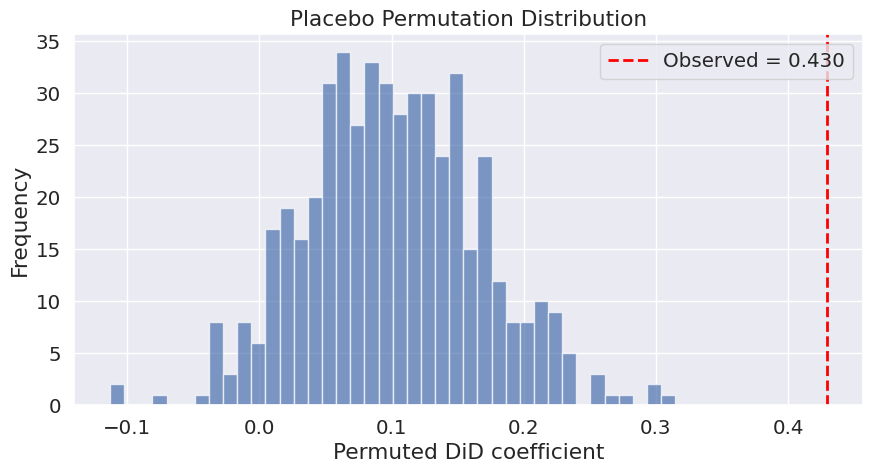

In [ ]:
permuted_betas, permutation_p_value = placebo_permutation_test(did_panel_placebo, n_permutations=500)

### Placebo test result

The difference-in-difference (DiD) effect size obtained from observation was 0.4296, whereas the mean of 500 permuted effects sizes was 0.1007, and the standard deviation was 0.0658.

None of the 500 permuted estimates took on an extreme value as compared to the DiD effect size from observation. This suggests that the observed DiD effect size falls far out of the possible distribution of the effect size obtained from a random relabeling of treatment status in the matched pairs.

Thus, this offers some robustness support for the observed DiD pattern, but in itself is not sufficient to verify the identifying assumptions of the DiD design.

### Approximate E-value sensitivity analysis

The E-value can be viewed as the measure of sensitivity regarding possible unobserved confounders. It reflects the degree of association which would need to be present between the unobserved confounder and both GitHub Actions use and commits in order to eliminate the DiD effect found.

As the outcome is measured on a continuous scale, the DiD estimator is converted to a risk ratio scale before calculating the E-value. Hence, the value obtained must be considered as an approximate sensitivity measure.


In [ ]:
import numpy as np

def compute_e_value(beta, outcome_sd):
    # Convert the DiD coefficient to an approximate risk-ratio scale
    cohens_d = beta / outcome_sd
    approx_rr = np.exp(0.91 * cohens_d)

    if approx_rr < 1:
        approx_rr = 1 / approx_rr

    e_value = approx_rr + np.sqrt(approx_rr * (approx_rr - 1))

    print(f"Cohen's d (approx.): {cohens_d:.3f}")
    print(f"Approximate risk ratio: {approx_rr:.3f}")
    print(f"E-value: {e_value:.3f}")
    print(f"\nInterpretation: an unmeasured confounder would need to be associated with both "
          f"treatment and outcome by a risk ratio of at least {e_value:.2f} each, above and "
          f"beyond the measured covariates, to fully explain away the observed effect.")
    return e_value

# Use the coefficient and outcome dispersion from the final PsmPy DiD analysis
observed_did_beta = float(did_result_psmpy.params["did"])
outcome_sd = did_panel_placebo["log_commits"].std()
e_value_result = compute_e_value(beta=observed_did_beta, outcome_sd=outcome_sd)

Cohen's d (approx.): 0.279
Approximate risk ratio: 1.289
E-value: 1.900

Interpretation: an unmeasured confounder would need to be associated with both treatment and outcome by a risk ratio of at least 1.90 each, above and beyond the measured covariates, to fully explain away the observed effect.


### E-value result

E-value Approximation Is 1.90. This means that in order to explain the difference-in-differences estimate obtained, the confounding factor needs to have correlations with both the exposure and the outcome which exceed 1.90 above those associated with the other variables.

It should be noted that such approximation is approximate and should be interpreted with caution.

### DiD Assumption Checks

One of the key assumptions underlying the DiD approach is that without the intervention, the treated and the control entities would have followed similar outcome paths.

This assumption can never be tested directly because the outcome paths of the treated units without the treatment are not observable. Pre-treatment behavior is therefore analyzed using
(i) a graphical examination of the trends,
(ii) an event study approach, and
(iii) a Wald test of the pre-treatment parameters.


### 1. Visual parallel-trends check

Plot of average log monthly commits by event month for the treated repository and its matched control. The goal is to graphically evaluate whether there is a big difference between the trend lines of the two before using GitHub Actions.

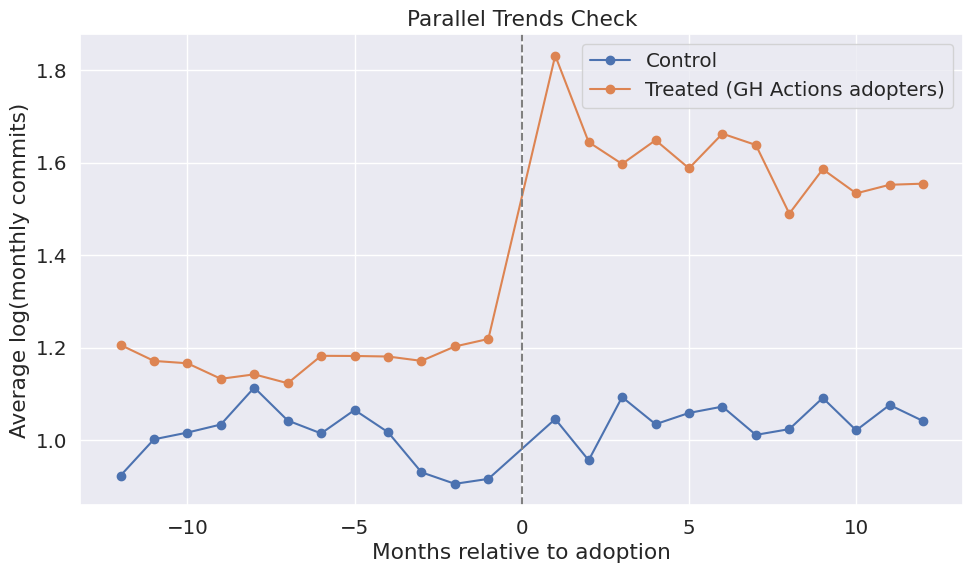

In [ ]:
def plot_parallel_trends(did_panel):
    trend = did_panel.groupby(["treated", "event_month"], as_index=False)["log_commits"].mean()
    plt.figure(figsize=(10, 6))
    for status, label in [(0, "Control"), (1, "Treated (GH Actions adopters)")]:
        subset = trend[trend["treated"] == status]
        plt.plot(subset["event_month"], subset["log_commits"], marker="o", label=label)
    plt.axvline(0, linestyle="--", color="gray")
    plt.xlabel("Months relative to adoption")
    plt.ylabel("Average log(monthly commits)")
    plt.title("Parallel Trends Check")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_parallel_trends(did_panel_psmpy)


### 2. Event-study model

The event-study model estimates separate treatment coefficients for individual months before and after GitHub Actions adoption.. Specifically, the month that precedes the adoption (Month -1) is taken as the base period. Therefore, each coefficient calculated represents the change in the treated-control difference in the specific event month compared to Month -1.

Pre-treatment coefficients are particularly important when it comes to analyzing any systematic difference in trends before the treatment. Post-treatment coefficients show how the treated-control difference evolves after adoption.

In [ ]:
def run_event_study(did_panel, window_months=12, reference_month=-1):
    panel = did_panel.copy()
    panel["month"] = pd.to_datetime(panel["month"])  # Ensure a datetime index for panel estimation

    event_vars = {}
    for m in range(-window_months, window_months + 1):
        if m in (reference_month, 0):
            continue
        name = f"lead_m{abs(m)}" if m < 0 else f"lag_p{m}"
        panel[name] = ((panel["event_month"] == m) & (panel["treated"] == 1)).astype(int)
        event_vars[m] = name

    formula = "log_commits ~ 1 + " + " + ".join(event_vars.values()) + " + EntityEffects + TimeEffects"
    reg_panel = panel.set_index(["repo_name", "month"]).sort_index()
    model = PanelOLS.from_formula(formula, data=reg_panel, drop_absorbed=True, check_rank=False)
    result = model.fit(cov_type="clustered", cluster_entity=True)
    print(result.summary)
    return result, event_vars


event_result, event_vars = run_event_study(did_panel_psmpy, window_months=12)

                          PanelOLS Estimation Summary                           
Dep. Variable:            log_commits   R-squared:                        0.0185
Estimator:                   PanelOLS   R-squared (Between):              0.0159
No. Observations:               15024   R-squared (Within):               0.0290
Date:                Mon, Aug 24 2026   R-squared (Overall):              0.0208
Time:                        10:01:10   Log-likelihood                -2.014e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      11.734
Entities:                         626   P-value                           0.0000
Avg Obs:                       24.000   Distribution:                F(23,14279)
Min Obs:                       24.000                                           
Max Obs:                       24.000   F-statistic (robust):             3.8270
                            

### Event-study coefficient plot

Plotted are the event study coefficient estimates along with their 95% confidence intervals relative to month -1, denoted by 0.

Coefﬁcients prior to adoption are used to measure pre-treatment differences, while coefﬁcients post adoption are used to examine changes in the difference estimated after adopting GitHub Actions.

/tmp/ipykernel_2002/4070681314.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "lower": ci.loc[name][0],
/tmp/ipykernel_2002/4070681314.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "upper": ci.loc[name][1],


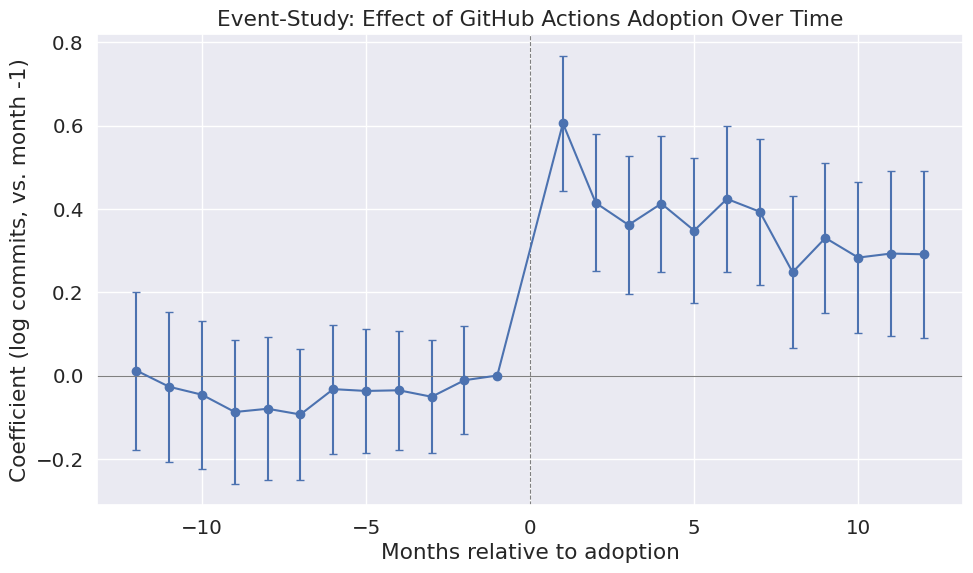

In [ ]:

# Plot event-study coefficients relative to the pre-adoption reference month
coef_rows = []
ci = event_result.conf_int()
for m, name in event_vars.items():
    coef_rows.append({
        "event_month": m,
        "coef": event_result.params[name],
        "lower": ci.loc[name][0],
        "upper": ci.loc[name][1],
    })
coef_rows.append({"event_month": -1, "coef": 0.0, "lower": 0.0, "upper": 0.0})  # Reference month

coef_df = pd.DataFrame(coef_rows).sort_values("event_month")

plt.figure(figsize=(10, 6))
plt.errorbar(
    coef_df["event_month"], coef_df["coef"],
    yerr=[coef_df["coef"] - coef_df["lower"], coef_df["upper"] - coef_df["coef"]],
    fmt="o-", capsize=3,
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, linestyle="--", color="gray", linewidth=0.8)
plt.xlabel("Months relative to adoption")
plt.ylabel("Coefficient (log commits, vs. month -1)")
plt.title("Event-Study: Effect of GitHub Actions Adoption Over Time")
plt.tight_layout()
plt.show()


### Joint test of pre-treatment coefficients

While the coefficients before treatment can be individually tested, the test for parallel trends becomes more meaningful if the pre-treatment coefficients are jointly tested.

H0: The pre-treatment event study coefficients are jointly equal to zero relative to the month -1 reference period.

H1: At least one of the pre-treatment coefficients differs from zero.

Failing to reject the null hypothesis implies that there is no significant differential pre-treatment trend in the data.

In [ ]:
from linearmodels.panel.results import WaldTestStatistic

lead_names = [name for m, name in event_vars.items() if m < 0]
joint_test = event_result.wald_test(formula=" = ".join(lead_names) + " = 0")
print(joint_test)

Linear Equality Hypothesis Test
H0: Linear equality constraint is valid
Statistic: 4.7238
P-value: 0.9438
Distributed: chi2(11)


### Parallel-trends assessment

The combined Wald test statistic for the 11 pre-treatment coefficient values results in chisq(11) = 4.72, p = 0.944. Thus, the null hypothesis of joint equality to zero of the pre-treatment coefficients cannot be rejected.

Out of the 11 pre-treatment coefficients, none is statistically significant at the 5% significance level. All pre-treatment coefficients therefore provide little evidence of systematic differences before adoption.

Overall, the data do not give strong reasons to believe in systematic differential trends before treatment for the treated and matched control repositories. Still, these results should be seen as a support to the validity of the parallel-trends assumption, and not as its validation.

## 12. Technique 4 — Doubly Robust Difference-in-Differences

DR-DiD is based on a combination of a propensity-score model with an outcome-regression model, providing an extra way of estimating the effect of treatment, taking into account the differences between treated and control repositories.

The sample used in this analysis is identical to that used in the main DiD analysis, and includes 318 treated repositories and 318 control repositories.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


### Build the DR-DiD dataset

The monthly DiD panel is converted into a repository-level dataset. For each repository, average log commit activity is calculated separately for the pre-treatment and post-treatment periods, and the difference between these averages is used as the outcome change.

Pre-treatment repository characteristics are then added as covariates.

In [ ]:
def build_drdid_dataset(did_panel, unit_df):
    panel = did_panel.copy()
    if "repo_name" in panel.columns:
        panel = panel.rename(columns={"repo_name": "repo_full_name"})

    # Mean pre-treatment outcome
    y0 = (panel[panel["post"] == 0].groupby("repo_full_name")["log_commits"].mean().rename("y0"))

    # Mean post-treatment outcome
    y1 = (panel[panel["post"] == 1].groupby("repo_full_name")["log_commits"].mean().rename("y1"))

    # Covariates measured before treatment
    lang_cols = [c for c in unit_df.columns if c.startswith("lang_")]

    covariate_cols = ["log_pre_commits","age_at_index_days","log_stars","log_forks"] + lang_cols

    unit_indexed = unit_df.set_index("repo_full_name")

    covariates = unit_indexed[covariate_cols]
    treatment = unit_indexed["treatment"].rename("D")

    df = pd.concat([y0, y1, treatment, covariates],axis=1,join="inner").dropna().copy()

    # Ensure numeric model inputs
    df["D"] = df["D"].astype(int)
    df["y0"] = df["y0"].astype(float)
    df["y1"] = df["y1"].astype(float)
    df[covariate_cols] = df[covariate_cols].astype(float)

    # Repository-level outcome change
    df["delta_y"] = df["y1"] - df["y0"]

    print("==========================================")
    print("DR-DID DATASET")
    print("==========================================")
    print(f"Total repositories : {len(df)}")
    print(f"Treated repositories: {(df['D']==1).sum()}")
    print(f"Control repositories: {(df['D']==0).sum()}")
    print(f"Covariates used: {len(covariate_cols)}")

    return df, covariate_cols

In [ ]:
  def estimate_drdid_att(df, covariate_cols, trim_level=0.995):
    data = df.copy()
    D = data["D"].to_numpy(dtype=float)
    delta_y = data["delta_y"].to_numpy(dtype=float)
    # Add regression intercept
    X = sm.add_constant(data[covariate_cols].astype(float),has_constant="add")

    # 1. Propensity score model: P(D=1 | X)
    ps_model = sm.Logit(D, X).fit(disp=False)
    ps = ps_model.predict(X).to_numpy()

    # Bound propensity scores away from 1 for numerical stability
    ps = np.minimum(ps, 1 - 1e-6)

    # Exclude control repositories with extreme propensity scores
    keep = np.ones(len(data), dtype=bool)
    keep[(D == 0) & (ps >= trim_level)] = False

    data = data.loc[keep].copy()
    D = D[keep]
    delta_y = delta_y[keep]
    ps = ps[keep]
    X = X.loc[keep]

    # 2. Outcome regression among controls: model untreated outcome change
    control_mask = (D == 0)
    reg_model = sm.OLS(delta_y[control_mask],X.loc[control_mask]).fit()
    m0_hat = reg_model.predict(X).to_numpy()


    # 3. Doubly robust DiD ATT components
    # Treated-group weights
    w_treat = D
    # Propensity-odds weights for controls
    w_control = ps * (1 - D) / (1 - ps)
    # Residualized outcome change
    residual_change = delta_y - m0_hat
    # Mean residual change for treated repositories
    eta_treat = (np.sum(w_treat * residual_change)/ np.sum(w_treat))

    # Weighted mean residual change for control repositories
    eta_control = (
        np.sum(w_control * residual_change)
        / np.sum(w_control)
    )

    # Doubly robust ATT estimate
    dr_att = eta_treat - eta_control
    print()
    print("==========================================")
    print("DR-DID ATT")
    print("==========================================")
    print(f"ATT: {dr_att:.6f}")
    print(f"Propensity model pseudo-R²: {ps_model.prsquared:.4f}")
    print(f"Control outcome model R²: {reg_model.rsquared:.4f}")
    print(f"Observations retained after trimming: {len(data)}")

    return {
        "att": dr_att,
        "ps_model": ps_model,
        "outcome_model": reg_model,
        "analysis_df": data,
        "ps": ps
    }


### Bootstrap uncertainty estimation

Bootstrapping is used to estimate the uncertainty in the DR-DiD ATT. The models for estimating propensity scores and control outcomes are estimated for each bootstrapped sample before calculating the ATTs.

The process is repeated 1,000 times with a fixed random seed.

In [ ]:
def bootstrap_drdid(df,covariate_cols,trim_level=0.995,n_boot=1000,seed=42):
    rng = np.random.default_rng(seed)
    estimates = []
    n = len(df)
    for _ in range(n_boot):
        idx = rng.choice(np.arange(n),size=n,replace=True)
        boot = df.iloc[idx].copy()
        # Skip resamples that contain only one treatment group
        if boot["D"].nunique() < 2:
            continue
        try:
            D = boot["D"].to_numpy(dtype=float)
            delta_y = boot["delta_y"].to_numpy(dtype=float)
            X = sm.add_constant(
                boot[covariate_cols].astype(float),
                has_constant="add"
            )
            # -------------------------
            # Propensity score model
            # -------------------------
            ps_model = sm.Logit(D, X).fit(disp=False,maxiter=100)
            ps = ps_model.predict(X).to_numpy()
            ps = np.minimum(ps, 1 - 1e-6)

            # Apply the same propensity-score trimming rule
            keep = np.ones(len(boot), dtype=bool)
            keep[(D == 0) & (ps >= trim_level)] = False

            D2 = D[keep]
            dy2 = delta_y[keep]
            ps2 = ps[keep]
            X2 = X.loc[keep]

            if len(np.unique(D2)) < 2:
                continue
            # Control outcome model
            control_mask = (D2 == 0)
            if control_mask.sum() <= len(covariate_cols) + 1:
                continue
            reg_model = sm.OLS(dy2[control_mask],X2.loc[control_mask]).fit()
            m0_hat = reg_model.predict(X2).to_numpy()
            # Doubly robust DiD estimate
            residual_change = dy2 - m0_hat
            w_treat = D2
            w_control = ps2 * (1 - D2) / (1 - ps2)
            eta_treat = (np.sum(w_treat * residual_change)/ np.sum(w_treat) )
            eta_control = (np.sum(w_control * residual_change)/ np.sum(w_control))
            att = eta_treat - eta_control
            if np.isfinite(att):
                estimates.append(att)

        except Exception:
            continue

    estimates = np.asarray(estimates)

    if len(estimates) == 0:
        raise RuntimeError("No successful bootstrap iterations.")

    se = estimates.std(ddof=1)

    ci_low = np.percentile(estimates, 2.5)
    ci_high = np.percentile(estimates, 97.5)

    print()
    print("==========================================")
    print("BOOTSTRAP DR-DID")
    print("==========================================")
    print(f"Successful iterations: {len(estimates)}")
    print(f"Bootstrap SE: {se:.6f}")
    print(f"95% percentile CI: ({ci_low:.6f}, {ci_high:.6f})")

    return {
        "estimates": estimates,
        "se": se,
        "ci": (ci_low, ci_high)
    }


### Run the DR-DiD analysis

In [ ]:
drdid_df, drdid_covariates = build_drdid_dataset(did_panel_psmpy,unit_df)

drdid_result = estimate_drdid_att(drdid_df,drdid_covariates,trim_level=0.995)

drdid_boot = bootstrap_drdid(drdid_df,drdid_covariates,trim_level=0.995,n_boot=1000,seed=42)

att = drdid_result["att"]

pct_effect = (np.exp(att) - 1) * 100

print()
print("==========================================")
print("FINAL DR-DID RESULT")
print("==========================================")
print(f"DR-DID ATT        : {att:.4f}")
print(f"Bootstrap SE      : {drdid_boot['se']:.4f}")
print(
    f"95% CI            : "
    f"({drdid_boot['ci'][0]:.4f}, "
    f"{drdid_boot['ci'][1]:.4f})"
)
print(f"Approx. % effect  : {pct_effect:.2f}%")

DR-DID DATASET
Total repositories : 626
Treated repositories: 313
Control repositories: 313
Covariates used: 15

DR-DID ATT
ATT: 0.393133
Propensity model pseudo-R²: 0.0155
Control outcome model R²: 0.0921
Observations retained after trimming: 626


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



BOOTSTRAP DR-DID
Successful iterations: 1000
Bootstrap SE: 0.078477
95% percentile CI: (0.245002, 0.548589)

FINAL DR-DID RESULT
DR-DID ATT        : 0.3931
Bootstrap SE      : 0.0785
95% CI            : (0.2450, 0.5486)
Approx. % effect  : 48.16%


### DR-DiD result
The DR-DiD model was built using 626 repositories, consisting of 313 treatment and 313 control repositories. None of the repositories were eliminated by the propensity-score trimming criterion.

The ATT value is 0.3931, which translates into an estimated effect of about 48.16%. The bootstrap standard error is 0.0785, while the 95% percentile confidence interval runs from 0.2450 to 0.5486.

The DR-DiD estimate is comparable to the basic DiD estimate of 0.4296, providing consistent results in direction and broadly similar magnitude across the two longitudinal approaches.